# 📗 딥러닝 기초 종합 과제

## 손글씨 숫자 분류 모델의 학습·비교·저장·추론 흐름 완성하기

여러분은 손글씨 숫자 판독 기능을 점검하는 AI 개발팀의 구성원입니다. 이번 과제에서는
정확도 하나만 확인하지 않고 `데이터 → 모델 → 학습·검증 → 비교 → 저장·복원 → 추론`의
전체 흐름을 완성합니다.

> ✅ **4점은 필수 역량을 모두 달성한 상 수준**입니다. 5점은 4점 기준을 먼저 충족한 뒤
> 해당 문제의 선택 심화를 구현·검증·해석한 +α입니다.

### 🧭 진행 순서

1. 문제 1~4의 필수 TODO를 순서대로 완성합니다.
2. 각 코드 셀 아래 자동 검증이 `PASS`인지 확인합니다.
3. 실제 출력과 그래프를 근거로 설명 답안을 작성합니다.
4. 시간이 남으면 원하는 5점 도전을 수행합니다.
5. 마지막 셀에서 필수 B1~B4가 모두 `PASS`인지 확인합니다.

절대 accuracy는 채점하지 않습니다. 올바른 split, 학습·검증 흐름, 공정 비교,
checkpoint 복원과 출력 기반 해석을 평가합니다.


## 0. 🛠️ 환경과 공통 설정

이 과제는 외부 이미지 파일을 내려받지 않는 `load_digits`를 사용합니다. 무료 Colab에서
GPU가 배정되지 않아도 전체 흐름을 실행할 수 있습니다.

### 먼저 확인할 것

- 실행 장치가 CPU인지 GPU인지
- Python·PyTorch·scikit-learn 버전
- seed·batch size·learning rate·최대 epoch·Early Stopping 설정
- 데이터의 원본 shape와 class 수

> 🔒 문제 1~3에서는 test index만 예약합니다. test `Dataset`과 `DataLoader`는 모델과
> checkpoint가 모두 확정된 문제 4의 마지막 단계에서만 만듭니다.


In [1]:
import copy
import hashlib
import importlib.util
import inspect
import json
import os
import platform
import random
import subprocess
import sys
from pathlib import Path

# Colab 기본 runtime에 없는 package만 설치합니다.
required_modules = {
    "torch": "torch",
    "sklearn": "scikit-learn",
    "matplotlib": "matplotlib",
    "numpy": "numpy",
}
missing_packages = [
    package
    for module, package in required_modules.items()
    if importlib.util.find_spec(module) is None
]
if missing_packages and os.environ.get("DL_ASSIGNMENT_SKIP_INSTALL") != "1":
    subprocess.check_call(
        [sys.executable, "-m", "pip", "install", "-q", *missing_packages]
    )

import matplotlib
import matplotlib.pyplot as plt
import numpy as np
import sklearn
import torch
import torch.nn as nn
from sklearn.datasets import load_digits
from sklearn.model_selection import train_test_split
from torch.utils.data import (
    DataLoader,
    RandomSampler,
    SequentialSampler,
    TensorDataset,
)

SEED = 42
BATCH_SIZE = 64
LEARNING_RATE = 0.005
EPOCHS = 30  # 최대 epoch
EARLY_STOPPING_PATIENCE = 3
EARLY_STOPPING_MIN_DELTA = 0.002
NUM_CLASSES = 10
DROPOUT_RATE = 0.2

TODO_IDS = [
    "TODO-B1-SPLIT-1", "TODO-B1-SPLIT-2", "TODO-B1-LOADER-1",
    "TODO-B1-LOADER-2", "TODO-B1-NCHW", "TODO-B1-DEVICE-1",
    "TODO-B1-DEVICE-2", "TODO-B1-CONTRACT", "TODO-B1-CHALLENGE",
    "TODO-B2-MLP", "TODO-B2-CNN", "TODO-B2-SHAPE-1",
    "TODO-B2-SHAPE-2", "TODO-B2-SHAPE-3", "TODO-B2-PARAMS",
    "TODO-B2-LOSS", "TODO-B2-OPT-MLP", "TODO-B2-OPT-CNN",
    "TODO-B2-MODE", "TODO-B2-CHALLENGE",
    "TODO-B3-TRAIN-1", "TODO-B3-TRAIN-2", "TODO-B3-TRAIN-3",
    "TODO-B3-TRAIN-4", "TODO-B3-TRAIN-5", "TODO-B3-TRAIN-6",
    "TODO-B3-TRAIN-7", "TODO-B3-TRAIN-8",
    "TODO-B3-VALID-1", "TODO-B3-VALID-2",
    "TODO-B3-VALID-3", "TODO-B3-VALID-4", "TODO-B3-CURVE",
    "TODO-B3-CHALLENGE",
    "TODO-B4-BEST", "TODO-B4-CHECKPOINT", "TODO-B4-LAST-CHECKPOINT", "TODO-B4-SAVE",
    "TODO-B4-LOAD-MODEL", "TODO-B4-LOAD-LAST-MODEL", "TODO-B4-LOAD-OPT", "TODO-B4-START",
    "TODO-B4-RESUME", "TODO-B4-INFERENCE", "TODO-B4-CHALLENGE",
]

def set_all_seeds(seed=SEED):
    # Python·NumPy·PyTorch의 난수 시작점을 고정합니다.
    random.seed(seed)
    np.random.seed(seed)
    torch.manual_seed(seed)
    if torch.cuda.is_available():
        torch.cuda.manual_seed_all(seed)
    # cuDNN을 사용하는 경우에도 가능한 범위에서 결정적 경로를 선택합니다.
    if hasattr(torch.backends, "cudnn"):
        torch.backends.cudnn.deterministic = True
        torch.backends.cudnn.benchmark = False

set_all_seeds()
# 작은 CPU 과제에서는 thread 수를 줄이면 실행 편차와 overhead가 작아집니다.
torch.set_num_threads(1)

DEVICE = (
    torch.device("cuda", torch.cuda.current_device())
    if torch.cuda.is_available()
    else torch.device("cpu")
)

def TODO(message):
    raise NotImplementedError(f"TODO를 완성하세요: {message}")

ENVIRONMENT = {
    "python": platform.python_version(),
    "torch": torch.__version__,
    "sklearn": sklearn.__version__,
    "numpy": np.__version__,
    "matplotlib": matplotlib.__version__,
    "device": str(DEVICE),
    "gpu": torch.cuda.get_device_name(DEVICE) if DEVICE.type == "cuda" else None,
    "seed": SEED,
    "max_epochs": EPOCHS,
    "early_stopping_patience": EARLY_STOPPING_PATIENCE,
    "early_stopping_min_delta": EARLY_STOPPING_MIN_DELTA,
}
print(json.dumps(ENVIRONMENT, ensure_ascii=False, indent=2))


{
  "python": "3.13.15",
  "torch": "2.11.0+cpu",
  "sklearn": "1.6.1",
  "numpy": "2.1.3",
  "matplotlib": "3.10.0",
  "device": "cpu",
  "gpu": null,
  "seed": 42,
  "max_epochs": 30,
  "early_stopping_patience": 3,
  "early_stopping_min_delta": 0.002
}


In [2]:
# load_digits는 package에 포함된 toy dataset이므로 데이터 파일 다운로드가 없습니다.
digits = load_digits()
source_images = digits.images.astype(np.float32)
source_labels = digits.target.astype(np.int64)

# 원래 0~16 범위의 픽셀을 0~1로 정규화하고 grayscale channel을 추가합니다.
images_all = torch.from_numpy(source_images).unsqueeze(1) / 16.0
labels_all = torch.from_numpy(source_labels)
all_indices = np.arange(len(source_labels), dtype=np.int64)

source_fingerprint = hashlib.sha256(
    source_images.tobytes() + source_labels.tobytes()
).hexdigest()

assert images_all.shape == (1797, 1, 8, 8)
assert images_all.dtype == torch.float32
assert labels_all.shape == (1797,)
assert labels_all.dtype == torch.int64
print(
    {
        "samples": len(labels_all),
        "image_shape": tuple(images_all.shape[1:]),
        "classes": sorted(labels_all.unique().tolist()),
        "normalized_pixel_min": float(images_all.min()),
        "normalized_pixel_max": float(images_all.max()),
        "source_fingerprint": source_fingerprint,
    }
)


{'samples': 1797, 'image_shape': (1, 8, 8), 'classes': [0, 1, 2, 3, 4, 5, 6, 7, 8, 9], 'normalized_pixel_min': 0.0, 'normalized_pixel_max': 1.0, 'source_fingerprint': 'faf2d98f61250c1cdc0b114323133d3c58da04f5c5d28bb78e4bde3c936a75b1'}


# 1. 🧱 데이터 분할·DataLoader·배치 입구 검사

## 문제 배경

모델에 들어가는 배치의 shape나 dtype이 잘못되면 학습이 시작되지 않거나 잘못된 계산이
진행될 수 있습니다. 이번 문제에서는 데이터를 누수 없이 나누고, 첫 배치가 모델이 기대하는
규칙을 지키는지 확인합니다.

## 이 문제에서 배우는 것

- **stratified split:** 숫자 0~9의 비율을 가능한 한 유지하며 데이터 나누기
- **NCHW:** 이미지 Tensor의 표준 순서 `[배치, 채널, 높이, 너비]`
- **device:** 모델과 Tensor가 계산되는 CPU 또는 GPU
- **batch contract:** 모델에 들어가기 전 배치가 지켜야 할 입구 규칙

## 수행 순서

1. seed 42로 70/15/15 train·validation·test index를 만듭니다.
2. train은 shuffle, validation은 고정 순서로 DataLoader를 만듭니다.
3. 일부러 NHWC가 된 batch를 NCHW로 되돌리고 값 보존을 검사합니다.
4. image·label을 모델과 같은 device로 이동합니다.
5. shape·dtype·finite·label 범위·device를 모두 검사합니다.

## 제출 결과물

- split 크기·class 분포·교집합 0 확인
- sampler 종류와 첫 batch 정보
- NHWC → NCHW 수정 전후 shape
- 배치 입구 검사 결과와 `문제 1 필수 자동 검증: PASS`

## ⚠️ 자주 발생하는 실수

- validation이나 test까지 shuffle해야 성능이 좋아진다고 오해하기
- NHWC를 NCHW로 바꾸는 `permute()` 순서를 반대로 작성하기
- image만 device로 옮기고 label은 CPU에 남겨두기
- 다중 분류 label을 `float32`로 바꾸기

## 🚀 5점 도전 미리보기

첫 오류에서 멈추지 않고 여러 오류를 한 번에 모아 보여 주는 검사기를 만듭니다.


In [3]:
# 첫 split에서 70% train과 30% remainder를 만듭니다.
train_indices, remainder_indices = train_test_split(
    all_indices,
    test_size=0.30,
    random_state=SEED,
    stratify=source_labels,
) #()"TODO-B1-SPLIT-1: 70/30 stratified split")

# remainder를 같은 크기의 validation/test로 나눠 전체 70/15/15를 만듭니다.
valid_indices, final_test_indices = train_test_split(
    remainder_indices,
    test_size=0.50,
    random_state=SEED,
    stratify=source_labels[remainder_indices],
) #("TODO-B1-SPLIT-2: remainder를 validation/test로 분리")

# 세 split의 교집합이 없고 모든 sample을 정확히 한 번 포함하는지 검사합니다.
train_index_set = set(map(int, train_indices))
valid_index_set = set(map(int, valid_indices))
test_index_set = set(map(int, final_test_indices))
assert train_index_set.isdisjoint(valid_index_set)
assert train_index_set.isdisjoint(test_index_set)
assert valid_index_set.isdisjoint(test_index_set)
assert len(train_index_set | valid_index_set | test_index_set) == len(all_indices)
assert (len(train_indices), len(valid_indices), len(final_test_indices)) == (1257, 270, 270)

# 각 split에 0~9 class가 모두 존재하는지도 확인합니다.
assert set(source_labels[train_indices]) == set(range(NUM_CLASSES))
assert set(source_labels[valid_indices]) == set(range(NUM_CLASSES))
assert set(source_labels[final_test_indices]) == set(range(NUM_CLASSES))

split_fingerprint = hashlib.sha256(
    np.concatenate(
        [
            np.sort(train_indices),
            np.array([-1], dtype=np.int64),
            np.sort(valid_indices),
            np.array([-2], dtype=np.int64),
            np.sort(final_test_indices),
        ]
    ).astype(np.int64).tobytes()
).hexdigest()

# 문제 1~3에서는 train/validation Dataset만 생성합니다.
train_dataset = TensorDataset(
    images_all[train_indices], labels_all[train_indices]
)
valid_dataset = TensorDataset(
    images_all[valid_indices], labels_all[valid_indices]
)

# 모델별로 같은 shuffle 순서를 재생성할 수 있는 factory입니다.
def make_train_loader(seed=SEED):
    generator = torch.Generator().manual_seed(seed)
    return DataLoader(
        train_dataset,
        batch_size=BATCH_SIZE,
        shuffle=True,
        num_workers=0,
        generator=generator,
    )

# 문제 1 검사용 train/validation loader를 만듭니다.
train_loader = make_train_loader()#("TODO-B1-LOADER-1: shuffle=True train loader")
valid_loader = DataLoader(
    valid_dataset,
    batch_size=BATCH_SIZE,
    shuffle=False,
    num_workers=0,
) #("TODO-B1-LOADER-2: shuffle=False validation loader")

assert isinstance(train_loader.sampler, RandomSampler)
assert isinstance(valid_loader.sampler, SequentialSampler)
assert train_loader.batch_size == valid_loader.batch_size == BATCH_SIZE
assert train_loader.dataset is train_dataset
assert valid_loader.dataset is valid_dataset
assert len(train_loader.dataset) == len(train_indices)
assert len(valid_loader.dataset) == len(valid_indices)

batch_images, batch_labels = next(iter(train_loader))
# 일부 이미지 도구의 NHWC 오류를 의도적으로 재현합니다.
batch_nhwc = batch_images.permute(0, 2, 3, 1).contiguous()

def restore_nchw(batch):
    # TODO-B1-NCHW: 입력으로 받은 NHWC만 사용해 NCHW를 복원합니다.
    return batch.permute(0, 3, 1, 2).contiguous() #("TODO-B1-NCHW: NHWC를 NCHW로 복원")

restored_nchw = restore_nchw(batch_nhwc)
# 함수가 받은 NHWC와 복원한 NCHW의 왕복 값 보존을 비교합니다.
torch.testing.assert_close(
    restored_nchw.permute(0, 2, 3, 1), batch_nhwc
)

# 작은 Conv2d의 parameter device를 batch 이동 기준으로 사용합니다.
device_probe = nn.Conv2d(1, 4, kernel_size=3, padding=1).to(DEVICE)
expected_device = next(device_probe.parameters()).device
images_device = restored_nchw.to(expected_device) #("TODO-B1-DEVICE-1: image를 model device로 이동")
labels_device = batch_labels.to(expected_device) #("TODO-B1-DEVICE-2: label을 model device로 이동")

# device 이동 전후 값이 그대로인지도 검사합니다.
torch.testing.assert_close(images_device.cpu(), restored_nchw)
torch.testing.assert_close(labels_device.cpu(), batch_labels)

def assert_batch_contract(images, labels, device):
  assert images.ndim == 4, f"이미지는 4차원이어야 함 (N,C,H,W), 실제: {images.ndim}"
  assert images.shape[1] == 1, f"채널은 1이어야 함, 실제: {images.shape[1]}"
  assert images.shape[2] == 8 and images.shape[3] == 8, f"이미지는 8x8이어야 함, 실제: {images.shape[2]}x{images.shape[3]}"
  assert images.dtype == torch.float32, f"이미지는 float32여야 함, 실제: {images.dtype}"
  assert torch.isfinite(images).all(), "이미지에 NaN 또는 Inf가 있음"
  assert labels.dtype == torch.int64, f"라벨은 int64(long)여야 함, 실제: {labels.dtype}"
  assert labels.min().item() >= 0, f"라벨 최솟값이 0보다 작음: {labels.min().item()}"
  assert labels.max().item() < NUM_CLASSES, f"라벨 최댓값이 클래스 개수를 초과함: {labels.max().item()}"
  assert images.device == device, f"이미지 device 불일치: {images.device} != {device}"
  assert labels.device == device, f"라벨 device 불일치: {labels.device} != {device}"

    # TODO-B1-CONTRACT: 아래 모든 계약을 fail-fast 방식으로 검사합니다.
    # ("TODO-B1-CONTRACT: shape/dtype/finite/label/device 검사")
  return {
        "batch": len(images),
        "image_shape": tuple(images.shape),
        "image_dtype": str(images.dtype),
        "label_dtype": str(labels.dtype),
        "label_min": int(labels.min().item()),
        "label_max": int(labels.max().item()),
        "device": str(device),
    }

batch_contract_report = assert_batch_contract(
    images_device, labels_device, expected_device
)
probe_logits = device_probe(images_device)
assert probe_logits.shape == (len(images_device), 4, 8, 8)
assert torch.isfinite(probe_logits).all()

SPLIT_SUMMARY = {
    "train": len(train_indices),
    "validation": len(valid_indices),
    "test_reserved": len(final_test_indices),
    "split_fingerprint": split_fingerprint,
}
PROBLEM_1_EVIDENCE = {
    "class_distribution": {
        "train": np.bincount(
            source_labels[train_indices], minlength=NUM_CLASSES
        ).tolist(),
        "validation": np.bincount(
            source_labels[valid_indices], minlength=NUM_CLASSES
        ).tolist(),
        "test_reserved": np.bincount(
            source_labels[final_test_indices], minlength=NUM_CLASSES
        ).tolist(),
    },
    "samplers": {
        "train": type(train_loader.sampler).__name__,
        "validation": type(valid_loader.sampler).__name__,
    },
    "shape_conversion": {
        "nhwc_before": list(batch_nhwc.shape),
        "nchw_after": list(restored_nchw.shape),
        "roundtrip_values_preserved": True,
    },
}
CORE_B1_PASS = True
print("문제 1 필수 자동 검증: PASS")
print(json.dumps(SPLIT_SUMMARY, ensure_ascii=False, indent=2))
print(json.dumps(PROBLEM_1_EVIDENCE, ensure_ascii=False, indent=2))
print(batch_contract_report)


문제 1 필수 자동 검증: PASS
{
  "train": 1257,
  "validation": 270,
  "test_reserved": 270,
  "split_fingerprint": "395e4910bef3d38577b9a1f644af30fd917a0c5d65b4446827ca2b97a7568533"
}
{
  "class_distribution": {
    "train": [
      124,
      127,
      124,
      128,
      127,
      127,
      127,
      125,
      122,
      126
    ],
    "validation": [
      27,
      27,
      27,
      27,
      27,
      28,
      27,
      27,
      26,
      27
    ],
    "test_reserved": [
      27,
      28,
      26,
      28,
      27,
      27,
      27,
      27,
      26,
      27
    ]
  },
  "samplers": {
    "train": "RandomSampler",
    "validation": "SequentialSampler"
  },
  "shape_conversion": {
    "nhwc_before": [
      64,
      8,
      8,
      1
    ],
    "nchw_after": [
      64,
      1,
      8,
      8
    ],
    "roundtrip_values_preserved": true
  }
}
{'batch': 64, 'image_shape': (64, 1, 8, 8), 'image_dtype': 'torch.float32', 'label_dtype': 'torch.int64', 'label_min': 0,

### ✍️ 문제 1 필수 결과 해석 - 직접 작성

실제 출력값을 인용하여 아래 세 질문에 답하세요.

1. stratified 70/15/15 split과 train-only shuffle이 필요한 이유를 2문장으로 설명하세요.
2. NHWC를 NCHW로 되돌리고, image·label·model을 같은 device에 둬야 하는 이유를 2문장으로 설명하세요.
3. 실제 `batch_contract_report`의 image shape·dtype·label 범위·device를 기록하세요.

> **답안 작성 공간**  
> 1. stratified split을 쓰지 않으면 특정 숫자 클래스가 한쪽으로 몰릴 수 있다. train만 shuffle하는 이유는 매epoch마다 고루 학습하기 위해서고 validation은 SequentialSampler로 고정해 일관되게 평가하기 위해서다.

> 2. Pytorch의 Conv2d는 (N, C, H, W) 순서를 가정하고 계산하기 때문에 NHWC를 NCHW로 되돌린것이고 서로다른 device에 있는 텐서는 연산이 불가능하기 때문에 image, label, model을 모두 같은device로 맞춰야한다.  

> 3. image shape은 (64, 1, 8, 8), dtype은 torch.float32, label dtype은 torch.int64, 범위는 0~9다. device는 cpu이다.


In [4]:
# 과제가 쉬웠다면 도전해보세요! - 5점 도전 B1
CHALLENGE_B1_DONE = True
CHALLENGE_B1_PASS = False

def collect_batch_contract_errors(images, labels, device):
    if not CHALLENGE_B1_DONE:
        return []

    errors = []

    if images.ndim != 4:
        errors.append("image_ndim")
    if images.shape[1] != 1:
        errors.append("image_channel")
    if images.shape[2] != 8 or images.shape[3] != 8:
        errors.append("image_shape")
    if images.dtype != torch.float32:
        errors.append("image_dtype")
    if not torch.isfinite(images).all():
        errors.append("image_finite")
    if labels.dtype != torch.int64:
        errors.append("label_dtype")
    if labels.min().item() < 0 or labels.max().item() >= NUM_CLASSES:
        errors.append("label_range")
    if images.device != device:
        errors.append("image_device")
    if labels.device != device:
        errors.append("label_device")

    return errors

    # TODO-B1-CHALLENGE:
    # shape/dtype/finite/label/device의 모든 오류명을 list로 모으세요.
    # raise NotImplementedError("TODO-B1-CHALLENGE를 완성하세요.")

if CHALLENGE_B1_DONE:
    broken_images = batch_nhwc.to(expected_device, dtype=torch.float64)
    broken_labels = labels_device.clone()
    broken_labels[0] = NUM_CLASSES
    broken_labels[1] = -1
    detected_errors = collect_batch_contract_errors(
        broken_images, broken_labels, expected_device
    )
    expected_errors = {"image_shape", "image_dtype", "label_range"}
    assert expected_errors <= set(detected_errors)
    CHALLENGE_B1_PASS = True
    print("5점 도전 B1 자동 검증: PASS", detected_errors)
else:
    print("5점 도전 B1: SKIPPED - 필수 점수 감점 없음")


5점 도전 B1 자동 검증: PASS ['image_channel', 'image_shape', 'image_dtype', 'label_range']


### 🚀 5점 도전 B1 결과 해석 - 수행한 경우 작성

이번 도전의 `fail-fast`는 “첫 오류에서 즉시 중단하는 방식”을 뜻합니다.

1. 실제 `detected_errors` 목록을 기록하세요.
2. 여러 오류를 한 번에 모으는 방식이 첫 오류에서 멈추는 방식보다 디버깅에 유리한 점을
   2문장으로 설명하세요.

> **답안 작성 공간**  
> 1. ['image_channel', 'image_shape', 'image_dtype', 'label_range']
> 2. 오류를 한번에 모으는 방식은 한번의 실행으로 4가지 문제를 동시에 보여주기 때문에 종합적으로 점검하고 고칠 수 있어 디버깅 효율이 좋아진다.


# 2. 🧠 ImageMLP와 CNN 모델 완성

## 문제 배경

MLP는 8×8 픽셀을 처음부터 한 줄로 펼치지만, CNN은 작은 필터로 주변 픽셀의 공간 관계를
먼저 찾습니다. 이번 문제에서는 두 모델의 구조를 직접 완성하고 중간 shape와 파라미터 수를
확인합니다.

## 이 문제에서 배우는 것

- `nn.Module`·`forward()`·raw logits의 역할
- `Conv → BatchNorm → ReLU → Pool`의 shape 변화
- MLP와 CNN의 이미지 처리 방식 차이
- Dropout·BatchNorm 때문에 train/eval mode를 구분해야 하는 이유

## 수행 순서

1. `Flatten-Linear-ReLU-Dropout-Linear` ImageMLP를 완성합니다.
2. `Conv-BN-ReLU-Pool` 블록 두 개를 가진 CNN을 완성합니다.
3. `input → feature map → flatten → logits` shape를 기록합니다.
4. 두 모델의 trainable parameter 수를 코드로 계산합니다.
5. raw logits에 `CrossEntropyLoss`와 Adam을 연결합니다.
6. finite loss·gradient와 train/eval mode 차이를 검증합니다.

> 💡 `CrossEntropyLoss`는 내부에서 log-softmax에 해당하는 계산을 포함하므로 모델 끝에
> Softmax를 따로 추가하지 않습니다.

## 제출 결과물

- 두 모델 클래스와 `[B,10]` logits
- CNN shape trace와 두 모델의 파라미터 수
- loss·gradient·Dropout·BatchNorm mode 검증
- `문제 2 필수 자동 검증: PASS`

## ⚠️ 자주 발생하는 실수

- `CrossEntropyLoss` 앞에서 Softmax를 한 번 더 적용하기
- pooling 뒤 feature map 크기를 계산하지 않고 Linear 입력 수를 추측하기
- validation에서도 `train()` mode를 유지해 Dropout을 켜 두기
- `zero_grad()`를 빼서 이전 batch의 gradient가 누적되게 하기

## 🚀 5점 도전 미리보기

forward hook으로 layer별 shape를 자동 수집하고, 수식으로 계산한 파라미터 수와 실제 값을
교차 검증합니다.


In [5]:
class ImageMLP(nn.Module):
    def __init__(self, dropout_rate=DROPOUT_RATE):
        super().__init__()
        # TODO-B2-MLP: 8×8 image를 펼쳐 hidden 64와 10개 logits로 연결합니다.
        self.network = nn.Sequential(
            nn.Flatten(),
            nn.Linear(8 * 8, 64),
            nn.ReLU(),
            nn.Dropout(dropout_rate),
            nn.Linear(64, NUM_CLASSES),
        ) #("TODO-B2-MLP: Flatten-Linear-ReLU-Dropout-Linear")

    def forward(self, images):
        return self.network(images)


class ImprovedCNN(nn.Module):
    def __init__(self, dropout_rate=DROPOUT_RATE):
        super().__init__()
        # TODO-B2-CNN: Conv-BN-ReLU-Pool block을 두 번 사용합니다.
        self.features = nn.Sequential(
            nn.Conv2d(1, 8, kernel_size=3, padding=1),
            nn.BatchNorm2d(8),
            nn.ReLU(),
            nn.MaxPool2d(2),
            nn.Conv2d(8, 16, kernel_size=3, padding=1),
            nn.BatchNorm2d(16),
            nn.ReLU(),
            nn.MaxPool2d(2),
        ) #("TODO-B2-CNN: Conv-Pool-Conv-Pool feature extractor")
        self.dropout = nn.Dropout(dropout_rate)
        self.classifier = nn.Linear(16 * 2 * 2, NUM_CLASSES)

    def forward(self, images):
        features = self.features(images)
        flattened = torch.flatten(features, start_dim=1)
        return self.classifier(self.dropout(flattened))


set_all_seeds(SEED)
mlp_model = ImageMLP().to(DEVICE)
set_all_seeds(SEED)
cnn_model = ImprovedCNN().to(DEVICE)


shape_probe_images = images_device[:16]

def trace_required_cnn_shapes(model, images):
    # 교안 11·12장의 핵심 흐름을 필수 결과로 직접 기록합니다.
    trace = {"input": tuple(images.shape)}
    x = model.features[0](images)
    trace["conv1"] = tuple(x.shape)
    x = model.features[1](x)
    x = model.features[2](x)
    x = model.features[3](x)
    trace["pool1"] = tuple(x.shape)
    x = model.features[4](x)
    trace["conv2"] = tuple(x.shape)
    x = model.features[5](x)
    x = model.features[6](x)
    x = model.features[7](x)
    trace["pool2"] = tuple(x.shape)
    return trace, x

cnn_shape_trace, traced_feature_map = trace_required_cnn_shapes(
    cnn_model, shape_probe_images
)
# TODO-B2-SHAPE-1~3: 최종 feature map·flatten·logits를 연결합니다.
cnn_feature_map = cnn_model.features(shape_probe_images) #("TODO-B2-SHAPE-1: CNN feature map")
cnn_flattened = torch.flatten(cnn_feature_map, start_dim=1) #("TODO-B2-SHAPE-2: feature map flatten")
cnn_logits = cnn_model.classifier(cnn_model.dropout(cnn_flattened)) #("TODO-B2-SHAPE-3: dropout 뒤 classifier logits")
mlp_logits = mlp_model(shape_probe_images)
torch.testing.assert_close(traced_feature_map, cnn_feature_map)

cnn_shape_trace["flatten"] = tuple(cnn_flattened.shape)
cnn_shape_trace["logits"] = tuple(cnn_logits.shape)
assert cnn_shape_trace == {
    "input": (16, 1, 8, 8),
    "conv1": (16, 8, 8, 8),
    "pool1": (16, 8, 4, 4),
    "conv2": (16, 16, 4, 4),
    "pool2": (16, 16, 2, 2),
    "flatten": (16, 64),
    "logits": (16, NUM_CLASSES),
}
assert mlp_logits.shape == (16, NUM_CLASSES)

def count_trainable_parameters(model):
    # TODO-B2-PARAMS: requires_grad=True인 parameter 원소 수를 합합니다.
    return sum(p.numel() for p in model.parameters() if p.requires_grad) #("TODO-B2-PARAMS: trainable parameter 수")

mlp_parameter_count = count_trainable_parameters(mlp_model)
cnn_parameter_count = count_trainable_parameters(cnn_model)
assert mlp_parameter_count > 0 and cnn_parameter_count > 0

# B2 loss/optimizer TODO: 두 모델에 같은 loss·optimizer family·lr를 연결합니다.
criterion = nn.CrossEntropyLoss() #("TODO-B2-LOSS: CrossEntropyLoss")
mlp_optimizer = torch.optim.Adam(mlp_model.parameters(), lr=LEARNING_RATE) #("TODO-B2-OPT-MLP: MLP Adam")
cnn_optimizer = torch.optim.Adam(cnn_model.parameters(), lr=LEARNING_RATE) #("TODO-B2-OPT-CNN: CNN Adam")

assert isinstance(criterion, nn.CrossEntropyLoss)
assert isinstance(mlp_optimizer, torch.optim.Adam)
assert isinstance(cnn_optimizer, torch.optim.Adam)
assert np.isclose(mlp_optimizer.param_groups[0]["lr"], LEARNING_RATE)
assert np.isclose(cnn_optimizer.param_groups[0]["lr"], LEARNING_RATE)
assert not any(
    isinstance(layer, (nn.Softmax, nn.LogSoftmax))
    for model in (mlp_model, cnn_model)
    for layer in model.modules()
)

# raw logits가 실제 gradient를 모든 trainable parameter로 전달하는지 확인합니다.
cnn_optimizer.zero_grad(set_to_none=True)
gradient_logits = cnn_model(images_device)
gradient_loss = criterion(gradient_logits, labels_device)
gradient_loss.backward()
assert gradient_logits.shape == (len(images_device), NUM_CLASSES)
assert torch.isfinite(gradient_loss)
assert all(
    parameter.grad is not None and torch.isfinite(parameter.grad).all()
    for parameter in cnn_model.parameters()
    if parameter.requires_grad
)

# TODO-B2-MODE: Dropout과 BatchNorm의 train/eval 동작을 각각 검증합니다.
set_all_seeds(SEED)
mode_probe_model = ImprovedCNN().to(DEVICE)
first_bn = next(
    layer for layer in mode_probe_model.modules()
    if isinstance(layer, nn.BatchNorm2d)
)
bn_mean_before = first_bn.running_mean.detach().clone()

mode_probe_model.train()
train_output_1 = mode_probe_model(shape_probe_images)
train_output_2 = mode_probe_model(shape_probe_images)
train_repeat_gap = (train_output_1 - train_output_2).abs().max().item()

bn_mean_after = first_bn.running_mean.detach().clone()
bn_running_delta = (bn_mean_after - bn_mean_before).abs().max().item()

mode_probe_model.eval()
with torch.no_grad():
    eval_output_1 = mode_probe_model(shape_probe_images)
    eval_output_2 = mode_probe_model(shape_probe_images)
eval_repeat_gap = (eval_output_1 - eval_output_2).abs().max().item() #("TODO-B2-MODE: train/eval Dropout gap과 BN running mean 변화")

assert train_repeat_gap > 0.0
assert bn_running_delta > 0.0
assert eval_repeat_gap <= 1e-7

MODEL_SUMMARY = {
    "mlp_parameters": mlp_parameter_count,
    "cnn_parameters": cnn_parameter_count,
    "cnn_shape_trace": cnn_shape_trace,
    "train_dropout_gap": train_repeat_gap,
    "bn_running_delta": bn_running_delta,
    "eval_repeat_gap": eval_repeat_gap,
}
CORE_B2_PASS = True
print("문제 2 필수 자동 검증: PASS")
print(json.dumps(MODEL_SUMMARY, ensure_ascii=False, indent=2))


문제 2 필수 자동 검증: PASS
{
  "mlp_parameters": 4810,
  "cnn_parameters": 1946,
  "cnn_shape_trace": {
    "input": [
      16,
      1,
      8,
      8
    ],
    "conv1": [
      16,
      8,
      8,
      8
    ],
    "pool1": [
      16,
      8,
      4,
      4
    ],
    "conv2": [
      16,
      16,
      4,
      4
    ],
    "pool2": [
      16,
      16,
      2,
      2
    ],
    "flatten": [
      16,
      64
    ],
    "logits": [
      16,
      10
    ]
  },
  "train_dropout_gap": 1.2337182760238647,
  "bn_running_delta": 0.11899212002754211,
  "eval_repeat_gap": 0.0
}


### ✍️ 문제 2 필수 결과 해석 - 직접 작성

1. 실제 CNN shape trace와 MLP/CNN 파라미터 수를 인용해 구조 차이를 설명하세요.
2. `train_dropout_gap`, `bn_running_delta`, `eval_repeat_gap`이 각각 무엇을 확인하는지
   3문장으로 설명하세요.
3. 출력 class가 10개인 이유와 모델 끝에 Softmax를 넣지 않은 이유를 설명하세요.

> **답안 작성 공간**  
> 1. (16,1,8,8)→conv1(16,8,8,8)→pool1(16,8,4,4)→conv2(16,16,4,4)→pool2(16,16,2,2)→flatten(16,64)→logits(16,10)처럼 채널은 늘리고 공간 크기는 줄이며 처리한다. MLP는 처음부터 Flatten으로 64개를 한 줄로 펴서 위치 정보를 초반에 잃는다. 파라미터 수는 MLP 4,810개, CNN 1,946개로 CNN이 더 적은데, Conv 필터가 가중치를 공유하기 때문이다.
> 2. train_dropout_gap(1.2337)은 train 모드에서 Dropout이 실제로 무작위 작동하는지 확인한다. bn_running_delta(0.1190)는 train 모드에서 BatchNorm이 통계를 실제로 누적하는지 확인한다. eval_repeat_gap(0.0)은 eval 모드에서 결과가 항상 동일하게 나오는지 확인한다.
> 3. 숫자 0~9, 10가지를 분류하므로 class는 10개다. CrossEntropyLoss가 내부에 softmax를 이미 포함하기 때문에 모델에 Softmax를 또 넣으면 이중 적용되어 계산이 틀어진다.


In [6]:
# 과제가 쉬웠다면 도전해보세요! - 5점 도전 B2
CHALLENGE_B2_DONE = True
CHALLENGE_B2_PASS = False

def collect_hook_shapes(model, sample):
    if not CHALLENGE_B2_DONE:
        return []

    hook_shape_trace = []

    def make_hook(layer_type_name):
      def hook(module, input, output):
          hook_shape_trace.append(
              {
                  "type": layer_type_name,
                  "shape": tuple(output.shape),
              }
          )
      return hook

    handles = []
    for layer in model.modules():
      if isinstance(layer, (nn.Conv2d, nn.MaxPool2d, nn.Linear)):
          layer_type_name = type(layer).__name__
          handle = layer.register_forward_hook(make_hook(layer_type_name))
          handles.append(handle)

    model.eval()
    with torch.no_grad():
      model(sample)

    for handle in handles:
      handle.remove()

    return hook_shape_trace

    # TODO-B2-CHALLENGE:
    # Conv2d/MaxPool2d/Linear forward hook을 등록하고 출력 shape를 모은 뒤
    # 모든 handle을 제거하세요.
    # raise NotImplementedError("TODO-B2-CHALLENGE를 완성하세요.")

if CHALLENGE_B2_DONE:
    hook_shape_trace = collect_hook_shapes(cnn_model, shape_probe_images)
    manual_cnn_parameter_budget = (
        (1 * 8 * 3 * 3 + 8) + (8 * 2)      # conv1 weight+bias, BN1 weight+bias
        + (8 * 16 * 3 * 3 + 16) + (16 * 2)  # conv2 weight+bias, BN2 weight+bias
        + (16 * 2 * 2 * NUM_CLASSES + NUM_CLASSES)  # classifier weight+bias
    )
    assert [row["type"] for row in hook_shape_trace] == [
        "Conv2d", "MaxPool2d", "Conv2d", "MaxPool2d", "Linear"
    ]
    assert manual_cnn_parameter_budget == cnn_parameter_count
    CHALLENGE_B2_PASS = True
    print(
        "5점 도전 B2 자동 검증: PASS",
        {
            "hook_shapes": hook_shape_trace,
            "manual_budget": manual_cnn_parameter_budget,
            "actual_parameters": cnn_parameter_count,
        },
    )
else:
    print("5점 도전 B2: SKIPPED - 필수 점수 감점 없음")


5점 도전 B2 자동 검증: PASS {'hook_shapes': [{'type': 'Conv2d', 'shape': (16, 8, 8, 8)}, {'type': 'MaxPool2d', 'shape': (16, 8, 4, 4)}, {'type': 'Conv2d', 'shape': (16, 16, 4, 4)}, {'type': 'MaxPool2d', 'shape': (16, 16, 2, 2)}, {'type': 'Linear', 'shape': (16, 10)}], 'manual_budget': 1946, 'actual_parameters': 1946}


### 🚀 5점 도전 B2 결과 해석 - 수행한 경우 작성

1. forward hook이 기록한 layer 순서와 각 출력 shape를 기록하세요.
2. 수식으로 계산한 CNN 파라미터 수와 PyTorch가 계산한 실제 값이 같은지 확인하세요.
3. shape와 파라미터 수를 두 방식으로 확인하는 것이 왜 유용한지 3문장으로 설명하세요.

> **답안 작성 공간**  
> 1. Conv2d → (16,8,8,8), MaxPool2d → (16,8,4,4), Conv2d → (16,16,4,4), MaxPool2d → (16,16,2,2), Linear → (16,10) 순서로 기록되어, 문제 2의 cnn_shape_trace와 동일한 흐름을 확인했다.
> 2. 수식으로 직접 계산한 manual_cnn_parameter_budget은 1,946개, PyTorch가 count_trainable_parameters로 계산한 cnn_parameter_count도 1,946개로 일치했다.
> 3. Forward Hook은 실제 실행 결과를 자동 기록하고, 수식 계산은 구조를 이론적으로 예측한 값이라 서로 독립적인 검증이 된다. 두 값이 일치하면 코드 구현과 구조 이해가 둘 다 맞았다는 뜻이고 어긋나면 어디에 실수가 있는지 바로 알 수 있다.


# 3. 🔁 학습·검증 루프와 MLP-CNN 공정 비교

## 문제 배경

모델 구조를 비교하려면 split·seed·최대 epoch·Early Stopping·batch size·loss·optimizer를 같게 유지해야
합니다. 조건이 다르면 결과 차이가 구조 때문인지 다른 설정 때문인지 판단할 수 없습니다.

## 이 문제에서 배우는 것

- 학습과 검증의 mode·gradient 처리 차이
- 표본 수를 반영한 loss·accuracy 누적
- 같은 조건에서 두 모델을 비교하는 방법
- train/validation 곡선으로 정상 학습과 과적합 신호 읽기

## 수행 순서

1. `train_one_epoch()`의 `train → zero_grad → forward → loss → backward → step` 흐름을 완성합니다.
2. `validate_one_epoch()`의 `eval → no_grad → forward → metric` 흐름을 완성합니다.
3. validation 중 parameter·buffer가 바뀌지 않는지 검사합니다.
4. MLP와 CNN에 동일한 최대 30 epoch·patience 3·min_delta 0.002 정책을 적용합니다.
5. train/validation loss·accuracy 4개 곡선을 그립니다.
6. loss 감소와 prediction diversity를 sanity check합니다.
7. 파라미터 수·best metric·shape를 포함한 비교 리포트를 만듭니다.

## 그래프 읽기 순서

1. train loss가 감소하는지 확인합니다.
2. validation loss도 함께 감소하는지 확인합니다.
3. train은 좋아지지만 validation이 나빠지는 시점이 있는지 봅니다.
4. accuracy만 보지 말고 loss와 함께 판단합니다.

## 제출 결과물

- 두 epoch 함수와 두 모델의 epoch별 로그·Early Stopping 상태
- 네 개의 학습 곡선
- 예측 붕괴 여부와 비교 리포트
- `문제 3 필수 자동 검증: PASS`

## ⚠️ 자주 발생하는 실수

- MLP와 CNN에 서로 다른 split·seed·학습 정책을 적용하기
- validation에서 gradient 계산을 끄지 않거나 parameter를 업데이트하기
- 가장 높은 accuracy와 가장 낮은 loss를 서로 다른 epoch에서 섞어 보고하기
- test 결과를 본 뒤 epoch나 Dropout을 다시 고르기

## 🚀 5점 도전 미리보기

Dropout만 제거한 CNN을 같은 조건으로 다시 학습하여 한 요소만 바꾼 통제 실험을 합니다.


In [7]:
def train_one_epoch(model, data_loader, loss_fn, optimizer, device):
    # TODO-B3-TRAIN-1: Dropout·BatchNorm을 학습 mode로 전환합니다.
    model.train() #("TODO-B3-TRAIN-1: model.train()")
    total_loss = 0.0
    total_correct = 0
    total_samples = 0

    for images, labels in data_loader:
        # TODO-B3-TRAIN-2: model과 같은 device로 이동합니다.
        images = images.to(device) #("TODO-B3-TRAIN-2: image device 이동")
        labels = labels.to(device) #("TODO-B3-TRAIN-3: label device 이동")

        # B3 train TODO 3~8: 한 mini-batch update 순서를 완성합니다.
        optimizer.zero_grad() #("TODO-B3-TRAIN-4: zero_grad")
        logits = model(images) #("TODO-B3-TRAIN-5: forward")
        loss = loss_fn(logits, labels) #("TODO-B3-TRAIN-6: loss")
        loss.backward() #("TODO-B3-TRAIN-7: backward")
        optimizer.step() #("TODO-B3-TRAIN-8: optimizer.step")

        # loss_fn의 mean을 sample 수로 되돌려 전체 sample 기준 평균을 만듭니다.
        batch_size = len(labels)
        total_loss += float(loss.detach().cpu()) * batch_size
        total_correct += int((logits.argmax(dim=1) == labels).sum().item())
        total_samples += batch_size

    return {
        "loss": total_loss / total_samples,
        "accuracy": total_correct / total_samples,
        "samples": total_samples,
    }


def validate_one_epoch(model, data_loader, loss_fn, device):
    # TODO-B3-VALID-1: Dropout·BatchNorm을 평가 mode로 전환합니다.
    model.eval() #("TODO-B3-VALID-1: model.eval()")
    total_loss = 0.0
    total_correct = 0
    total_samples = 0

    # validation 전 parameter와 BatchNorm buffer를 함께 snapshot합니다.
    state_before = {
        name: value.detach().cpu().clone()
        for name, value in model.state_dict().items()
    }

    # TODO-B3-VALID-2: gradient graph를 만들지 않습니다.
    with torch.no_grad(): #("TODO-B3-VALID-2: with torch.no_grad()"):
        for images, labels in data_loader:
            images = images.to(device)
            labels = labels.to(device)
            # B3 validation TODO 3~4: forward와 loss만 계산합니다.
            logits = model(images) #("TODO-B3-VALID-3: forward")
            loss = loss_fn(logits, labels) #("TODO-B3-VALID-4: loss")
            batch_size = len(labels)
            total_loss += float(loss.cpu()) * batch_size
            total_correct += int(
                (logits.argmax(dim=1) == labels).sum().item()
            )
            total_samples += batch_size

    state_after = {
        name: value.detach().cpu().clone()
        for name, value in model.state_dict().items()
    }
    changed_state_keys = [
        name
        for name in state_before
        if not torch.equal(state_before[name], state_after[name])
    ]
    if changed_state_keys:
        raise AssertionError(
            f"validation 중 parameter/buffer가 변경됨: {changed_state_keys}"
        )

    return {
        "loss": total_loss / total_samples,
        "accuracy": total_correct / total_samples,
        "samples": total_samples,
        "changed_state_keys": changed_state_keys,
    }


In [8]:
def optimizer_state_to_cpu(optimizer):
    # optimizer의 Tensor state를 CPU에 복사해 장비와 무관한 checkpoint를 만듭니다.
    snapshot = copy.deepcopy(optimizer.state_dict())
    for parameter_state in snapshot["state"].values():
        for name, value in list(parameter_state.items()):
            if torch.is_tensor(value):
                parameter_state[name] = value.detach().cpu().clone()
    return snapshot


def fit_model(
    model,
    optimizer,
    train_loader,
    valid_loader,
    max_epochs,
    patience=EARLY_STOPPING_PATIENCE,
    min_delta=EARLY_STOPPING_MIN_DELTA,
):
    history = {
        "train_loss": [],
        "train_accuracy": [],
        "valid_loss": [],
        "valid_accuracy": [],
    }
    epoch_records = []
    best_record = None
    last_record = None
    best_valid_loss = float("inf")
    patience_reference = float("inf")
    epochs_without_significant_improvement = 0
    stopped_early = False

    for epoch in range(1, max_epochs + 1):
        train_metrics = train_one_epoch(
            model, train_loader, criterion, optimizer, DEVICE
        )
        valid_metrics = validate_one_epoch(
            model, valid_loader, criterion, DEVICE
        )
        history["train_loss"].append(train_metrics["loss"])
        history["train_accuracy"].append(train_metrics["accuracy"])
        history["valid_loss"].append(valid_metrics["loss"])
        history["valid_accuracy"].append(valid_metrics["accuracy"])

        record = {
            "epoch": epoch,
            "valid_loss": float(valid_metrics["loss"]),
            "valid_accuracy": float(valid_metrics["accuracy"]),
            "model_state_dict": {
                name: value.detach().cpu().clone()
                for name, value in model.state_dict().items()
            },
            "optimizer_state_dict": optimizer_state_to_cpu(optimizer),
        }
        epoch_records.append(record)
        last_record = copy.deepcopy(record)

        # best는 추론·평가를 위해 실제 최저 validation loss를 기준으로 저장합니다.
        if valid_metrics["loss"] < best_valid_loss:
            best_valid_loss = float(valid_metrics["loss"])
            best_record = copy.deepcopy(record)

        # Early Stopping의 patience는 min_delta 이상 개선되었을 때만 초기화합니다.
        if valid_metrics["loss"] < patience_reference - min_delta:
            patience_reference = float(valid_metrics["loss"])
            epochs_without_significant_improvement = 0
        else:
            epochs_without_significant_improvement += 1

        print(
            f"epoch={epoch:02d} "
            f"train_loss={train_metrics['loss']:.4f} "
            f"train_acc={train_metrics['accuracy']:.4f} "
            f"valid_loss={valid_metrics['loss']:.4f} "
            f"valid_acc={valid_metrics['accuracy']:.4f} "
            f"early_stop_wait={epochs_without_significant_improvement}/{patience}"
        )

        if epochs_without_significant_improvement >= patience:
            stopped_early = True
            print(
                "Early Stopping:",
                f"epoch {epoch}에서 중단 "
                f"(patience={patience}, min_delta={min_delta})",
            )
            break

    assert best_record is not None and last_record is not None
    summary = {
        "max_epochs": max_epochs,
        "epochs_run": len(history["valid_loss"]),
        "stopped_early": stopped_early,
        "patience": patience,
        "min_delta": min_delta,
        "best_epoch": int(best_record["epoch"]),
        "best_valid_loss": float(best_record["valid_loss"]),
        "best_valid_accuracy_at_best_loss": float(
            best_record["valid_accuracy"]
        ),
        "last_epoch": int(last_record["epoch"]),
        "last_valid_loss": float(last_record["valid_loss"]),
        "best_record": best_record,
        "last_record": last_record,
    }
    return history, epoch_records, summary


def collect_predictions(model, data_loader, device):
    model.eval()
    predictions = []
    with torch.no_grad():
        for images, _ in data_loader:
            logits = model(images.to(device))
            predictions.extend(logits.argmax(dim=1).cpu().tolist())
    return predictions


# 두 모델에 같은 split·batch 순서·최대 epoch·Early Stopping 정책을 적용합니다.
set_all_seeds(SEED)
fair_mlp = ImageMLP().to(DEVICE)
fair_mlp_optimizer = torch.optim.Adam(
    fair_mlp.parameters(), lr=LEARNING_RATE
)
mlp_history, mlp_records, mlp_training_summary = fit_model(
    fair_mlp,
    fair_mlp_optimizer,
    make_train_loader(SEED),
    valid_loader,
    EPOCHS,
)

set_all_seeds(SEED)
fair_cnn = ImprovedCNN().to(DEVICE)
fair_cnn_optimizer = torch.optim.Adam(
    fair_cnn.parameters(), lr=LEARNING_RATE
)
cnn_history, cnn_records, cnn_training_summary = fit_model(
    fair_cnn,
    fair_cnn_optimizer,
    make_train_loader(SEED),
    valid_loader,
    EPOCHS,
)

# 예측 붕괴 여부는 각 모델의 validation-best state로 확인합니다.
best_mlp_for_validation = ImageMLP().to(DEVICE)
best_mlp_for_validation.load_state_dict(
    mlp_training_summary["best_record"]["model_state_dict"]
)
best_cnn_for_validation = ImprovedCNN().to(DEVICE)
best_cnn_for_validation.load_state_dict(
    cnn_training_summary["best_record"]["model_state_dict"]
)
mlp_predictions_valid = collect_predictions(
    best_mlp_for_validation, valid_loader, DEVICE
)
cnn_predictions_valid = collect_predictions(
    best_cnn_for_validation, valid_loader, DEVICE
)
mlp_prediction_diversity = len(set(mlp_predictions_valid))
cnn_prediction_diversity = len(set(cnn_predictions_valid))

assert mlp_history["train_loss"][-1] < mlp_history["train_loss"][0]
assert cnn_history["train_loss"][-1] < cnn_history["train_loss"][0]
assert mlp_prediction_diversity >= 2
assert cnn_prediction_diversity >= 2
assert all(
    np.isfinite(values).all()
    for history in (mlp_history, cnn_history)
    for values in history.values()
)


epoch=01 train_loss=1.9797 train_acc=0.5012 valid_loss=1.4942 valid_acc=0.7815 early_stop_wait=0/3
epoch=02 train_loss=1.0897 train_acc=0.8138 valid_loss=0.7230 valid_acc=0.8370 early_stop_wait=0/3
epoch=03 train_loss=0.5813 train_acc=0.8687 valid_loss=0.4606 valid_acc=0.8778 early_stop_wait=0/3
epoch=04 train_loss=0.4096 train_acc=0.8974 valid_loss=0.3381 valid_acc=0.9222 early_stop_wait=0/3
epoch=05 train_loss=0.3115 train_acc=0.9252 valid_loss=0.2697 valid_acc=0.9259 early_stop_wait=0/3
epoch=06 train_loss=0.2661 train_acc=0.9308 valid_loss=0.2321 valid_acc=0.9333 early_stop_wait=0/3
epoch=07 train_loss=0.2365 train_acc=0.9356 valid_loss=0.2083 valid_acc=0.9407 early_stop_wait=0/3
epoch=08 train_loss=0.1975 train_acc=0.9483 valid_loss=0.2065 valid_acc=0.9370 early_stop_wait=1/3
epoch=09 train_loss=0.1868 train_acc=0.9427 valid_loss=0.1901 valid_acc=0.9444 early_stop_wait=0/3
epoch=10 train_loss=0.1672 train_acc=0.9554 valid_loss=0.1735 valid_acc=0.9407 early_stop_wait=0/3
epoch=11 t

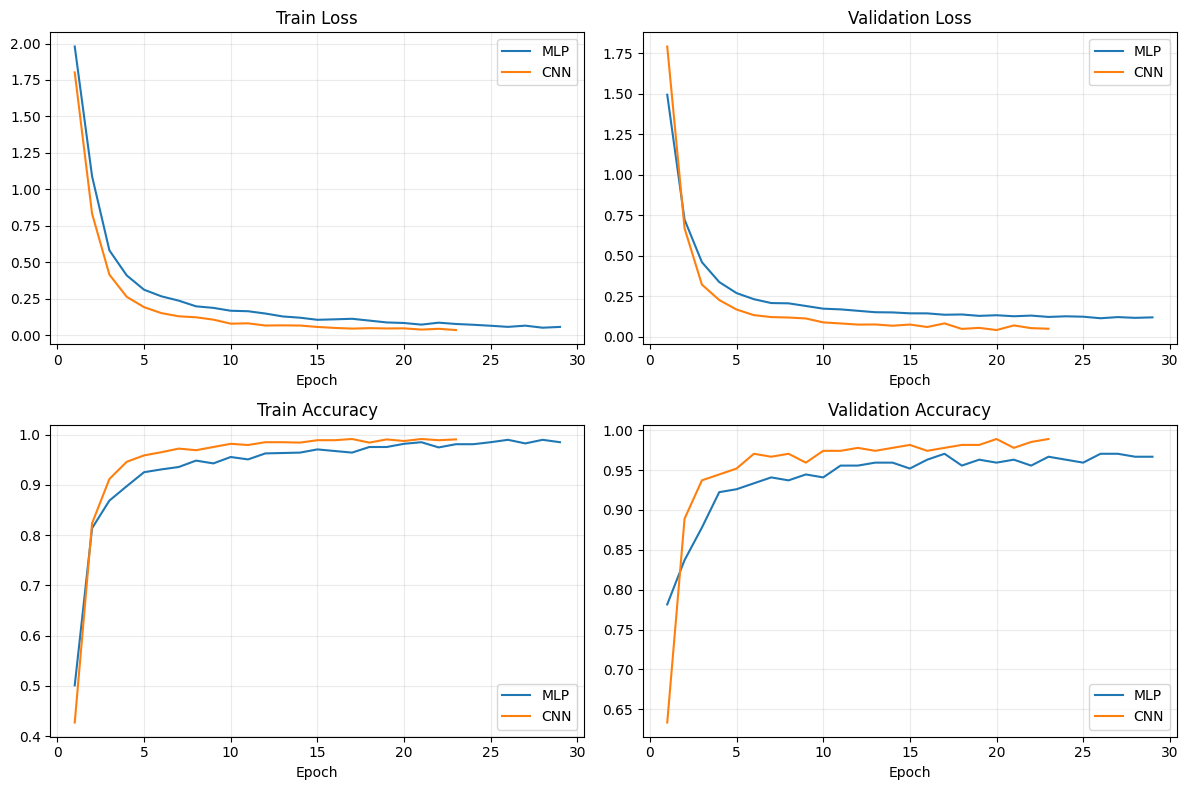

문제 3 필수 자동 검증: PASS
{
  "shared_policy": {
    "split_fingerprint": "395e4910bef3d38577b9a1f644af30fd917a0c5d65b4446827ca2b97a7568533",
    "seed": 42,
    "max_epochs": 30,
    "early_stopping_patience": 3,
    "early_stopping_min_delta": 0.002,
    "batch_size": 64,
    "learning_rate": 0.005,
    "loss": "CrossEntropyLoss",
    "optimizer_family": "Adam"
  },
  "MLP": {
    "parameters": 4810,
    "epochs_run": 29,
    "stopped_early": true,
    "best_epoch_by_min_valid_loss": 26,
    "best_valid_loss": 0.11448541158051402,
    "valid_accuracy_at_best_loss": 0.9703703703703703,
    "prediction_diversity": 10
  },
  "CNN": {
    "parameters": 1946,
    "epochs_run": 23,
    "stopped_early": true,
    "best_epoch_by_min_valid_loss": 20,
    "best_valid_loss": 0.04164329609937138,
    "valid_accuracy_at_best_loss": 0.9888888888888889,
    "prediction_diversity": 10,
    "shape_trace": {
      "input": [
        16,
        1,
        8,
        8
      ],
      "conv1": [
        16,
 

In [9]:
# TODO-B3-CURVE: Early Stopping으로 길이가 달라질 수 있는 두 history를 연결합니다.
curve_series = {}
for model_name, history in (("mlp", mlp_history), ("cnn", cnn_history)):
    curve_series[f"{model_name}_epochs"] = list(range(1, len(history["train_loss"]) + 1))
    curve_series[f"{model_name}_train_loss"] = history["train_loss"]
    curve_series[f"{model_name}_valid_loss"] = history["valid_loss"]
    curve_series[f"{model_name}_train_accuracy"] = history["train_accuracy"]
    curve_series[f"{model_name}_valid_accuracy"] = history["valid_accuracy"] #("TODO-B3-CURVE: 모델별 epoch와 train/valid loss/accuracy를 dictionary로 연결")
for model_name in ("mlp", "cnn"):
    epoch_values = curve_series[f"{model_name}_epochs"]
    assert len(epoch_values) == len(
        curve_series[f"{model_name}_train_loss"]
    )
    assert len(epoch_values) == len(
        curve_series[f"{model_name}_valid_loss"]
    )
    assert len(epoch_values) == len(
        curve_series[f"{model_name}_train_accuracy"]
    )
    assert len(epoch_values) == len(
        curve_series[f"{model_name}_valid_accuracy"]
    )

fig, axes = plt.subplots(2, 2, figsize=(12, 8))
for model_name, color in (("mlp", "tab:blue"), ("cnn", "tab:orange")):
    epoch_values = curve_series[f"{model_name}_epochs"]
    axes[0, 0].plot(
        epoch_values,
        curve_series[f"{model_name}_train_loss"],
        label=model_name.upper(),
        color=color,
    )
    axes[0, 1].plot(
        epoch_values,
        curve_series[f"{model_name}_valid_loss"],
        label=model_name.upper(),
        color=color,
    )
    axes[1, 0].plot(
        epoch_values,
        curve_series[f"{model_name}_train_accuracy"],
        label=model_name.upper(),
        color=color,
    )
    axes[1, 1].plot(
        epoch_values,
        curve_series[f"{model_name}_valid_accuracy"],
        label=model_name.upper(),
        color=color,
    )

axes[0, 0].set_title("Train Loss")
axes[0, 1].set_title("Validation Loss")
axes[1, 0].set_title("Train Accuracy")
axes[1, 1].set_title("Validation Accuracy")
for axis in axes.ravel():
    axis.set_xlabel("Epoch")
    axis.grid(alpha=0.25)
    axis.legend()
plt.tight_layout()
plt.show()

comparison_report = {
    "shared_policy": {
        "split_fingerprint": split_fingerprint,
        "seed": SEED,
        "max_epochs": EPOCHS,
        "early_stopping_patience": EARLY_STOPPING_PATIENCE,
        "early_stopping_min_delta": EARLY_STOPPING_MIN_DELTA,
        "batch_size": BATCH_SIZE,
        "learning_rate": LEARNING_RATE,
        "loss": type(criterion).__name__,
        "optimizer_family": "Adam",
    },
    "MLP": {
        "parameters": count_trainable_parameters(fair_mlp),
        "epochs_run": mlp_training_summary["epochs_run"],
        "stopped_early": mlp_training_summary["stopped_early"],
        "best_epoch_by_min_valid_loss": mlp_training_summary["best_epoch"],
        "best_valid_loss": mlp_training_summary["best_valid_loss"],
        "valid_accuracy_at_best_loss": mlp_training_summary[
            "best_valid_accuracy_at_best_loss"
        ],
        "prediction_diversity": mlp_prediction_diversity,
    },
    "CNN": {
        "parameters": count_trainable_parameters(fair_cnn),
        "epochs_run": cnn_training_summary["epochs_run"],
        "stopped_early": cnn_training_summary["stopped_early"],
        "best_epoch_by_min_valid_loss": cnn_training_summary["best_epoch"],
        "best_valid_loss": cnn_training_summary["best_valid_loss"],
        "valid_accuracy_at_best_loss": cnn_training_summary[
            "best_valid_accuracy_at_best_loss"
        ],
        "prediction_diversity": cnn_prediction_diversity,
        "shape_trace": cnn_shape_trace,
    },
}
CORE_B3_PASS = True
print("문제 3 필수 자동 검증: PASS")
print(json.dumps(comparison_report, ensure_ascii=False, indent=2))
print(
    "동적 해설:",
    f"MLP/CNN의 min-validation-loss checkpoint accuracy는 각각 "
    f"{comparison_report['MLP']['valid_accuracy_at_best_loss']:.4f}/"
    f"{comparison_report['CNN']['valid_accuracy_at_best_loss']:.4f}이고, "
    f"실행 epoch는 {comparison_report['MLP']['epochs_run']}/"
    f"{comparison_report['CNN']['epochs_run']}입니다. "
    "동일한 최대 학습·Early Stopping 정책을 적용했지만 구조 전체가 다르므로 "
    "CNN 한 요소만의 인과 효과로 일반화하지 않습니다.",
)


### ✍️ 문제 3 필수 결과 해석 - 직접 작성

실제 비교 출력과 곡선을 근거로 5~7문장으로 작성하세요.

- 두 모델의 파라미터 수와 best validation metric
- train/validation 곡선에서 보인 정상 학습 또는 과적합 신호
- CNN shape 흐름과 이미지 공간 구조의 관계
- prediction diversity가 확인하는 것
- 특정 accuracy를 채점하지 않고 한 번의 결과를 일반화하지 않는 이유
- 다음 실험에서 바꿀 요소 하나와 그대로 유지할 조건

> **답안 작성 공간**  
> MLP는 파라미터 4810개, CNN은 1946개로 CNN이 더 적었지만 best valid loss는 CNN(0.0416)이 MLP(0.1145)보다 더 낮았고 accuracy도 CNN(98.9%)이 MLP(97.0%)보다 높았다. 두 모델 다 train loss와 valid loss가 같이 꾸준히 줄어들어서 과적합 신호 없이 정상적으로 학습됐다. CNN은 (16,1,8,8)→(16,8,8,8)→(16,8,4,4)→...처럼 채널은 늘리고 이미지 크기는 줄이며 학습하는데, 이는 처음부터 flatten을 해버리는 MLP와 달리 이미지의 공간 구조를 살려서 학습한다는 뜻이다. prediction_diversity가 둘 다 10인 건 특정 숫자로만 예측이 쏠리지 않고 0~9를 골고루 예측했다는 뜻이다. 정확도 수치 자체를 채점하지 않는 이유는 seed나 초기화에 따라 값이 조금씩 달라질 수 있어서, 한 번의 결과만으로 어떤 구조가 무조건 낫다고 단정할 수 없기 때문이다. 다음엔 CNN에서 Dropout만 빼고 나머지 조건(split, seed, batch size, learning rate 등)은 그대로 유지해서 비교해볼 것이다.


In [10]:
# 과제가 쉬웠다면 도전해보세요! - 5점 도전 B3
CHALLENGE_B3_DONE = True
CHALLENGE_B3_PASS = False

if CHALLENGE_B3_DONE:
    set_all_seeds(SEED)
    no_dropout_cnn = ImprovedCNN(dropout_rate=0.0).to(DEVICE)
    no_dropout_optimizer = torch.optim.Adam(
        no_dropout_cnn.parameters(), lr=LEARNING_RATE
    )
    no_dropout_history, no_dropout_records, no_dropout_summary = fit_model(
        no_dropout_cnn, no_dropout_optimizer, make_train_loader(SEED), valid_loader, EPOCHS,
    )

    dropout_ablation_report = {
        "changed": {"dropout_rate": [DROPOUT_RATE, 0.0]},
        "fixed": {
            "seed": SEED,
            "split_fingerprint": split_fingerprint,
            "max_epochs": EPOCHS,
            "early_stopping_patience": EARLY_STOPPING_PATIENCE,
            "early_stopping_min_delta": EARLY_STOPPING_MIN_DELTA,
            "batch_size": BATCH_SIZE,
            "learning_rate": LEARNING_RATE,
            "optimizer_family": "Adam",
        },
        "baseline_cnn_best_valid_loss": cnn_training_summary["best_valid_loss"],
        "baseline_cnn_best_valid_accuracy": cnn_training_summary[
            "best_valid_accuracy_at_best_loss"
        ],
        "no_dropout_cnn_best_valid_loss": no_dropout_summary["best_valid_loss"],
        "no_dropout_cnn_best_valid_accuracy": no_dropout_summary[
            "best_valid_accuracy_at_best_loss"
        ],
    }
    # TODO-B3-CHALLENGE:
    # ImprovedCNN(dropout_rate=0.0)을 같은 seed/split/epoch/lr로 학습하고
    # 바뀐 변수·고정 조건·두 best validation metric을 report로 만드세요.
    CHALLENGE_B3_PASS = True
    print("5점 도전 B3:", json.dumps(dropout_ablation_report, ensure_ascii=False, indent=2))
else:
    print("5점 도전 B3: SKIPPED - 필수 점수 감점 없음")


epoch=01 train_loss=1.6944 train_acc=0.5386 valid_loss=1.7319 valid_acc=0.6556 early_stop_wait=0/3
epoch=02 train_loss=0.6589 train_acc=0.9085 valid_loss=0.5700 valid_acc=0.9148 early_stop_wait=0/3
epoch=03 train_loss=0.2771 train_acc=0.9610 valid_loss=0.2703 valid_acc=0.9370 early_stop_wait=0/3
epoch=04 train_loss=0.1513 train_acc=0.9769 valid_loss=0.1991 valid_acc=0.9481 early_stop_wait=0/3
epoch=05 train_loss=0.1043 train_acc=0.9881 valid_loss=0.1538 valid_acc=0.9667 early_stop_wait=0/3
epoch=06 train_loss=0.0722 train_acc=0.9912 valid_loss=0.1250 valid_acc=0.9704 early_stop_wait=0/3
epoch=07 train_loss=0.0524 train_acc=0.9960 valid_loss=0.1119 valid_acc=0.9667 early_stop_wait=0/3
epoch=08 train_loss=0.0439 train_acc=0.9968 valid_loss=0.1060 valid_acc=0.9778 early_stop_wait=0/3
epoch=09 train_loss=0.0367 train_acc=0.9976 valid_loss=0.1015 valid_acc=0.9815 early_stop_wait=0/3
epoch=10 train_loss=0.0265 train_acc=0.9968 valid_loss=0.0793 valid_acc=0.9741 early_stop_wait=0/3
epoch=11 t

### 🚀 5점 도전 B3 결과 해석 - 수행한 경우 작성

1. baseline CNN과 Dropout 제거 CNN의 실제 best validation metric을 기록하세요.
2. 두 실험에서 고정한 조건과 바꾼 조건 하나를 구분하여 작성하세요.
3. 한 번의 seed 결과만으로 Dropout의 일반적인 효과를 단정할 수 없는 이유를 포함해
   3~4문장으로 해석하세요.

> **답안 작성 공간**  
>1. baseline(Dropout 0.2)은 best valid loss 0.0416, accuracy 98.89%였고, Dropout을 제거한 CNN(0.0)은 best valid loss 0.0482, accuracy 98.52%로 baseline보다 아주 약간 낮은 성능을 보였다.
>2. 바꾼 조건은 dropout_rate 하나(0.2 → 0.0)이고, seed(42), split_fingerprint, max_epochs(30), early stopping patience(3)·min_delta(0.002), batch_size(64), learning_rate(0.005), optimizer(Adam)는 모두 동일하게 고정했다.
>3. Dropout 제거 모델은 epoch 11부터 train_acc가 계속 100%라 데이터를 완전히 외웠는데, valid 성능은 baseline과 큰 차이가 없었다(0.0416 vs 0.0482, 98.89% vs 98.52%). 다만 seed 42 한 번만 돌린 결과라, 다른 seed에서는 결과가 달라질 수 있어 이것만으로 Dropout 효과를 일반화할 수는 없다.


# 4. 💾 Best checkpoint 저장·복원·학습 재개

## 문제 배경

학습이 끝난 메모리 속 모델은 런타임이 종료되면 사라집니다. 모델 weight뿐 아니라
optimizer·epoch·설정·학습 이력까지 함께 저장해야 중단된 실험을 믿고 이어갈 수 있습니다.

## 이 문제에서 배우는 것

- 마지막 epoch와 validation-best epoch의 차이
- 평가·추론용 best checkpoint와 중단 지점 재개용 last checkpoint의 차이
- model·optimizer `state_dict`를 함께 저장하는 이유
- 새 모델에서 복원 전후 logits·class를 비교하는 방법
- `start_epoch`와 optimizer 상태를 이용한 학습 재개

## 수행 순서

1. validation loss가 가장 낮은 CNN epoch를 선택합니다.
2. best checkpoint에는 best model과 metric을, last checkpoint에는 마지막 model·optimizer·epoch를 저장합니다.
3. 저장 직전 validation logits를 보관합니다.
4. 새 CNN에 best checkpoint를 복원해 logits 허용오차와 class 완전 일치를 확인합니다.
5. 별도의 새 CNN·optimizer에 last checkpoint를 복원합니다.
6. 마지막 epoch 다음의 `start_epoch`를 계산하고 한 batch를 추가 학습합니다.
7. resume loss가 finite이고 파라미터가 실제로 업데이트되는지 검사합니다.

## 제출 결과물

- best·last epoch, validation loss와 두 checkpoint의 key
- reload logits 최대 차이·class 일치
- start epoch·resume loss·파라미터 업데이트
- `문제 4 필수 자동 검증: PASS`

## ⚠️ 자주 발생하는 실수

- 마지막 epoch 모델을 자동으로 best 모델이라고 간주하기
- 학습 재개용 파일에서 optimizer 상태나 epoch를 빼기
- checkpoint 호환성을 확인하기 전에 model state를 적용하기
- test metric을 확인한 뒤 모델 선택을 다시 시작하기

## 🚀 5점 도전 미리보기

schema·입력 shape·class 수·source/split fingerprint가 현재 실험과 맞는지 load 전에
검사하는 호환성 guard를 만듭니다.


In [11]:
# TODO-B4-BEST: validation loss가 가장 작은 epoch index를 선택합니다.
best_cnn_index = np.argmin(cnn_history["valid_loss"]) #("TODO-B4-BEST: validation loss가 가장 작은 index")
best_cnn_record = cnn_records[best_cnn_index]
best_cnn_epoch = int(best_cnn_record["epoch"])
best_cnn_valid_loss = float(best_cnn_record["valid_loss"])
best_cnn_valid_accuracy = float(best_cnn_record["valid_accuracy"])
last_cnn_record = cnn_training_summary["last_record"]
last_cnn_epoch = int(last_cnn_record["epoch"])
assert best_cnn_epoch == cnn_training_summary["best_epoch"]
assert last_cnn_epoch == cnn_training_summary["last_epoch"]
assert np.isclose(best_cnn_valid_loss, min(cnn_history["valid_loss"]))

# 저장 직전 기준 logits는 in-memory best state로 계산합니다.
pre_save_model = ImprovedCNN().to(DEVICE)
pre_save_model.load_state_dict(best_cnn_record["model_state_dict"])
pre_save_model.eval()
reload_probe_images, _ = next(iter(valid_loader))
reload_probe_images_device = reload_probe_images.to(DEVICE)
with torch.no_grad():
    pre_save_logits = pre_save_model(reload_probe_images_device)

common_config = {
    "model_class": "ImprovedCNN",
    "input_shape": [1, 8, 8],
    "num_classes": NUM_CLASSES,
    "dropout_rate": DROPOUT_RATE,
    "seed": SEED,
    "batch_size": BATCH_SIZE,
    "learning_rate": LEARNING_RATE,
    "max_epochs": EPOCHS,
    "early_stopping_patience": EARLY_STOPPING_PATIENCE,
    "early_stopping_min_delta": EARLY_STOPPING_MIN_DELTA,
}

# best는 평가·추론용입니다. optimizer는 last와 섞지 않습니다.
best_checkpoint = {
    "checkpoint_role": "best_for_inference",
    "model_state_dict": copy.deepcopy(best_cnn_record["model_state_dict"]), #("TODO-B4-CHECKPOINT: best model_state_dict")
    "epoch": best_cnn_epoch,
    "best_valid_loss": best_cnn_valid_loss,
    "best_valid_accuracy": best_cnn_valid_accuracy,
    "history": copy.deepcopy(cnn_history),
    "config": copy.deepcopy(common_config),
}

# last는 중단 지점 다음 epoch부터 학습을 이어가기 위한 기록입니다.
last_checkpoint = {
    "checkpoint_role": "last_for_resume",
    "model_state_dict": copy.deepcopy(
        last_cnn_record["model_state_dict"]
    ),
    "optimizer_state_dict": copy.deepcopy(last_cnn_record["optimizer_state_dict"]), #("TODO-B4-LAST-CHECKPOINT: last optimizer_state_dict")
    "epoch": last_cnn_epoch,
    "last_valid_loss": float(last_cnn_record["valid_loss"]),
    "history": copy.deepcopy(cnn_history),
    "config": copy.deepcopy(common_config),
}

assert {
    "checkpoint_role", "model_state_dict", "epoch",
    "best_valid_loss", "history", "config",
} <= set(best_checkpoint)
assert {
    "checkpoint_role", "model_state_dict", "optimizer_state_dict",
    "epoch", "last_valid_loss", "history", "config",
} <= set(last_checkpoint)
assert best_checkpoint["checkpoint_role"] == "best_for_inference"
assert last_checkpoint["checkpoint_role"] == "last_for_resume"

checkpoint_dir = Path("assignment_outputs") / "basic_friendly_v3"
checkpoint_dir.mkdir(parents=True, exist_ok=True)
best_checkpoint_path = checkpoint_dir / "best_cnn_checkpoint.pt"
last_checkpoint_path = checkpoint_dir / "last_cnn_checkpoint.pt"
# TODO-B4-SAVE: 용도가 다른 두 dictionary checkpoint를 각각 저장합니다.
torch.save(best_checkpoint, best_checkpoint_path)
torch.save(last_checkpoint, last_checkpoint_path)  #("TODO-B4-SAVE: best와 last checkpoint를 각각 torch.save")
assert best_checkpoint_path.exists() and last_checkpoint_path.exists()

load_kwargs = {"map_location": "cpu"}
if "weights_only" in inspect.signature(torch.load).parameters:
    load_kwargs["weights_only"] = False
loaded_best_checkpoint = torch.load(best_checkpoint_path, **load_kwargs)
loaded_last_checkpoint = torch.load(last_checkpoint_path, **load_kwargs)

# best checkpoint는 새 모델의 평가·추론 상태를 복원합니다.
restored_model = ImprovedCNN().to(DEVICE)
# TODO-B4-LOAD-MODEL
restored_model.load_state_dict(loaded_best_checkpoint["model_state_dict"]) #("TODO-B4-LOAD-MODEL: best model state를 새 모델에 복원")
restored_model.eval()
with torch.no_grad():
    restored_logits = restored_model(reload_probe_images_device)

torch.testing.assert_close(
    pre_save_logits, restored_logits, rtol=1e-5, atol=1e-6
)
assert torch.equal(
    pre_save_logits.argmax(dim=1), restored_logits.argmax(dim=1)
)

# last checkpoint는 별도 CPU model·optimizer에서 중단 지점 재개를 확인합니다.
resume_model = ImprovedCNN().cpu()
resume_optimizer = torch.optim.Adam(
    resume_model.parameters(), lr=LEARNING_RATE
)
# TODO-B4-LOAD-LAST-MODEL / TODO-B4-LOAD-OPT
resume_model.load_state_dict(loaded_last_checkpoint["model_state_dict"]) #("TODO-B4-LOAD-LAST-MODEL: last model state 복원")
resume_optimizer.load_state_dict(loaded_last_checkpoint["optimizer_state_dict"]) #("TODO-B4-LOAD-OPT: last optimizer state 복원")
# TODO-B4-START: 마지막으로 완료한 epoch 다음 번호입니다.
start_epoch = last_cnn_epoch +1 #("TODO-B4-START: last epoch 다음 번호")
assert start_epoch == last_cnn_epoch + 1
assert resume_optimizer.state_dict()["state"]

# 선택 심화 실행 여부와 무관한 필수 resume 결과를 위해 난수를 다시 고정합니다.
set_all_seeds(SEED)
resume_images, resume_labels = next(iter(make_train_loader(SEED)))
before_resume_parameters = [
    parameter.detach().clone() for parameter in resume_model.parameters()
]
resume_model.train()
resume_optimizer.zero_grad(set_to_none=True)
# TODO-B4-RESUME: 제공된 순서에서 forward를 완성합니다.
resume_logits = resume_model(resume_images.cpu()) #("TODO-B4-RESUME: resume batch forward")
resume_loss = criterion(resume_logits, resume_labels.cpu())
resume_loss.backward()
resume_optimizer.step()
after_resume_parameters = [
    parameter.detach() for parameter in resume_model.parameters()
]
resumed_parameter_update = any(
    not torch.equal(before, after)
    for before, after in zip(
        before_resume_parameters, after_resume_parameters
    )
)
assert resumed_parameter_update is True
assert torch.isfinite(resume_loss)

CHECKPOINT_SUMMARY = {
    "best_checkpoint_role": best_checkpoint["checkpoint_role"],
    "best_checkpoint_keys": sorted(best_checkpoint.keys()),
    "best_epoch": best_cnn_epoch,
    "best_valid_loss": best_cnn_valid_loss,
    "best_valid_accuracy": best_cnn_valid_accuracy,
    "last_checkpoint_role": last_checkpoint["checkpoint_role"],
    "last_checkpoint_keys": sorted(last_checkpoint.keys()),
    "last_epoch": last_cnn_epoch,
    "last_valid_loss": cnn_training_summary["last_valid_loss"],
    "start_epoch": start_epoch,
    "reload_max_abs_gap": float(
        (pre_save_logits - restored_logits).abs().max().cpu()
    ),
    "reload_class_exact": bool(
        torch.equal(
            pre_save_logits.argmax(dim=1),
            restored_logits.argmax(dim=1),
        )
    ),
    "resume_loss": float(resume_loss.detach().cpu()),
    "resume_parameter_update": resumed_parameter_update,
}
print("문제 4 best·last checkpoint·reload·resume 검증: PASS")
print(json.dumps(CHECKPOINT_SUMMARY, ensure_ascii=False, indent=2))


문제 4 best·last checkpoint·reload·resume 검증: PASS
{
  "best_checkpoint_role": "best_for_inference",
  "best_checkpoint_keys": [
    "best_valid_accuracy",
    "best_valid_loss",
    "checkpoint_role",
    "config",
    "epoch",
    "history",
    "model_state_dict"
  ],
  "best_epoch": 20,
  "best_valid_loss": 0.04164329609937138,
  "best_valid_accuracy": 0.9888888888888889,
  "last_checkpoint_role": "last_for_resume",
  "last_checkpoint_keys": [
    "checkpoint_role",
    "config",
    "epoch",
    "history",
    "last_valid_loss",
    "model_state_dict",
    "optimizer_state_dict"
  ],
  "last_epoch": 23,
  "last_valid_loss": 0.0497499275262709,
  "start_epoch": 24,
  "reload_max_abs_gap": 0.0,
  "reload_class_exact": true,
  "resume_loss": 0.0397288054227829,
  "resume_parameter_update": true
}


### ✍️ 문제 4 필수 결과 해석 - 직접 작성

실제 출력값을 인용하여 4~5문장으로 설명하세요.

- best epoch·last epoch와 validation loss
- reload logits 최대 차이와 class 일치 여부
- 복원된 start epoch
- resume loss와 파라미터 업데이트 여부
- optimizer 상태까지 복원해야 하는 이유

> **답안 작성 공간**  
> best epoch은 20(loss 0.0416), last epoch은 23(loss 0.0497)이었다. 저장 전후 logits 차이(reload_max_abs_gap)는 0.0, class도 100% 일치해(reload_class_exact: true) checkpoint 복원이 잘 이루어진걸 확인했다. start_epoch은 start_epoch=24로 정확히 계산됐고, 재개 후 resume loss는 0.0397, 파라미터도 실제로 업데이트되어(resume_parameter_update: true) 재개 학습이 정상 작동했다. optimizer 상태까지 복원해야 하는 이유는 Adam의 momentum 같은 내부 값이 없으면 학습이 처음부터 다시 시작하는 것처럼 불안정해지기 때문이다.


In [12]:
# 과제가 쉬웠다면 도전해보세요! - 5점 도전 B4
CHALLENGE_B4_DONE = True
CHALLENGE_B4_PASS = False

# schema와 fingerprint는 기초 필수가 아니라 호환성 guard 도전에서 추가합니다.
guarded_checkpoint = copy.deepcopy(best_checkpoint)
guarded_checkpoint.update(
    {
        "schema_version": 2,
        "source_fingerprint": source_fingerprint,
        "split_fingerprint": split_fingerprint,
    }
)

def validate_checkpoint_compatibility(
    candidate,
    expected_config,
    expected_source_fingerprint,
    expected_split_fingerprint,
):
    if not CHALLENGE_B4_DONE:
        return {}

    problems = []

    required_keys = {"model_state_dict", "config", "schema_version", "source_fingerprint", "split_fingerprint"}
    missing_keys = required_keys - set(candidate.keys())
    if missing_keys:
        problems.append(f"missing_keys: {sorted(missing_keys)}")

    if candidate.get("schema_version") != 2:
        problems.append(f"schema_version: expected 2, got {candidate.get('schema_version')}")

    candidate_config = candidate.get("config", {})
    for key, expected_value in expected_config.items():
        actual_value = candidate_config.get(key)
        if actual_value != expected_value:
            problems.append(
                f"config.{key}: expected {expected_value}, got {actual_value}"
            )

    if candidate.get("source_fingerprint") != expected_source_fingerprint:
        problems.append("source_fingerprint mismatch")

    if candidate.get("split_fingerprint") != expected_split_fingerprint:
        problems.append("split_fingerprint mismatch")

    if problems:
        raise ValueError("checkpoint 호환성 오류: " + "; ".join(problems))

    return {"compatible": True, "checked": sorted(required_keys)}
    # TODO-B4-CHALLENGE:
    # required key, schema_version=2, config, 두 fingerprint를 검사하고
    # 모든 불일치 항목을 포함한 ValueError를 발생시키세요.
    # raise NotImplementedError("TODO-B4-CHALLENGE를 완성하세요.")

if CHALLENGE_B4_DONE:
    expected_checkpoint_config = {
        "model_class": "ImprovedCNN",
        "input_shape": [1, 8, 8],
        "num_classes": NUM_CLASSES,
        "dropout_rate": DROPOUT_RATE,
    }
    # guard를 먼저 통과한 뒤에만 별도의 새 모델에 state를 적용합니다.
    compatibility_report = validate_checkpoint_compatibility(
        guarded_checkpoint,
        expected_checkpoint_config,
        source_fingerprint,
        split_fingerprint,
    )
    guard_probe_model = ImprovedCNN().cpu()
    guard_probe_model.load_state_dict(
        guarded_checkpoint["model_state_dict"]
    )
    deliberately_mismatched = copy.deepcopy(guarded_checkpoint)
    deliberately_mismatched["config"]["input_shape"] = [1, 28, 28]
    mismatch_detected = False
    mismatch_message = ""
    try:
        validate_checkpoint_compatibility(
            deliberately_mismatched,
            expected_checkpoint_config,
            source_fingerprint,
            split_fingerprint,
        )
    except ValueError as error:
        mismatch_detected = True
        mismatch_message = str(error)
    assert mismatch_detected is True
    assert "config.input_shape" in mismatch_message
    CHALLENGE_B4_PASS = True
    print(
        "5점 도전 B4 자동 검증: PASS",
        {
            "compatible": compatibility_report,
            "mismatch": mismatch_message,
            "guard_before_load": True,
        },
    )
else:
    print("5점 도전 B4: SKIPPED - 필수 점수 감점 없음")


5점 도전 B4 자동 검증: PASS {'compatible': {'compatible': True, 'checked': ['config', 'model_state_dict', 'schema_version', 'source_fingerprint', 'split_fingerprint']}, 'mismatch': 'checkpoint 호환성 오류: config.input_shape: expected [1, 8, 8], got [1, 28, 28]', 'guard_before_load': True}


### 🚀 5점 도전 B4 결과 해석 - 수행한 경우 작성

1. 정상 checkpoint의 compatibility report를 기록하세요.
2. 입력 shape를 28×28로 바꾼 checkpoint가 낸 실제 오류 메시지를 기록하세요.
3. load 전에 호환성을 검사하면 어떤 잘못된 실험 재사용을 예방할 수 있는지 3문장으로 설명하세요.

> **답안 작성 공간**  
> 1. {'compatible': True, 'checked': ['config', 'model_state_dict', 'schema_version', 'source_fingerprint', 'split_fingerprint']} — 필요한 5개 항목이 모두 검사를 통과했다.
> 2. "checkpoint 호환성 오류: config.input_shape: expected [1, 8, 8], got [1, 28, 28]" — 기대한 shape과 실제 shape이 다르다는 것을 정확히 짚어내는 메시지가 발생했다.
> 3.checkpoint를 불러오기 전에 현재 실험의 설정과 호환되는지 확인하면, 입력 shape나 데이터 조건 등이 다른 checkpoint를 실수로 불러오는 것을 예방할 수 있다. 이를 통해 잘못된 모델 복원이나 실험 결과의 오류를 줄일 수 있다.


# 🧪 최종 test - 이 단계에서만 DataLoader 생성

validation으로 모델 구조·epoch·checkpoint를 모두 확정한 뒤 예약해 둔 test index를
처음 사용합니다. 이 단계에서는 test DataLoader를 한 번 만들고 validation-best 모델을
한 번 평가합니다.

> 🔒 test 결과를 본 뒤 모델·epoch·Dropout·learning rate를 다시 고르면 test가 사실상
> validation 역할을 하게 됩니다. 그러면 일반화 성능을 독립적으로 확인할 수 없습니다.

## 확인할 결과

- test loader 생성 횟수: 1
- test 전체 평가 횟수: 1
- test loss·accuracy·prediction diversity
- 처음 10개 정답과 예측


In [13]:
TEST_LOADER_CREATION_CALLS = 0
TEST_EVALUATION_CALLS = 0

def build_final_test_loader():
    global TEST_LOADER_CREATION_CALLS
    if TEST_LOADER_CREATION_CALLS != 0:
        raise RuntimeError("test DataLoader는 최종 단계에서 한 번만 생성합니다.")
    TEST_LOADER_CREATION_CALLS += 1
    final_test_dataset = TensorDataset(
        images_all[final_test_indices],
        labels_all[final_test_indices],
    )
    return DataLoader(
        final_test_dataset,
        batch_size=BATCH_SIZE,
        shuffle=False,
        num_workers=0,
    )


def evaluate_test_once(model, data_loader, loss_fn, device):
    global TEST_EVALUATION_CALLS
    if TEST_EVALUATION_CALLS != 0:
        raise RuntimeError("전체 test 평가는 한 번만 허용됩니다.")
    TEST_EVALUATION_CALLS += 1
    model.eval()
    total_loss = 0.0
    total_correct = 0
    total_samples = 0
    all_truth = []
    all_predictions = []
    with torch.no_grad():
        for images, labels in data_loader:
            images = images.to(device)
            labels = labels.to(device)
            logits = model(images)
            loss = loss_fn(logits, labels)
            # TODO-B4-INFERENCE: raw logits에서 가장 큰 class index를 선택합니다.
            predictions = torch.argmax(logits, dim=1) #("TODO-B4-INFERENCE: logits에서 class ID 선택")
            batch_size = len(labels)
            total_loss += float(loss.cpu()) * batch_size
            total_correct += int(
                (predictions == labels).sum().item()
            )
            total_samples += batch_size
            all_truth.extend(labels.cpu().tolist())
            all_predictions.extend(predictions.cpu().tolist())
    return {
        "loss": total_loss / total_samples,
        "accuracy": total_correct / total_samples,
        "samples": total_samples,
        "truth": all_truth,
        "predictions": all_predictions,
    }


final_test_loader = build_final_test_loader()
test_result = evaluate_test_once(
    restored_model, final_test_loader, criterion, DEVICE
)
assert TEST_LOADER_CREATION_CALLS == 1
assert TEST_EVALUATION_CALLS == 1
assert test_result["samples"] == len(final_test_indices)
assert np.isfinite(test_result["loss"])
assert np.isfinite(test_result["accuracy"])
assert len(set(test_result["predictions"])) >= 2

prediction_pairs_preview = [
    {"truth": truth, "prediction": prediction}
    for truth, prediction in zip(
        test_result["truth"][:10],
        test_result["predictions"][:10],
    )
]
test_prediction_hash = hashlib.sha256(
    np.asarray(test_result["predictions"], dtype=np.int64).tobytes()
).hexdigest()

CORE_B4_PASS = True
print("문제 4 필수 자동 검증: PASS")
print(
    json.dumps(
        {
            "best_epoch": best_cnn_epoch,
            "last_epoch": last_cnn_epoch,
            "best_valid_loss": best_cnn_valid_loss,
            "test_loss": test_result["loss"],
            "test_accuracy": test_result["accuracy"],
            "test_samples": test_result["samples"],
            "prediction_diversity": len(
                set(test_result["predictions"])
            ),
            "truth_prediction_preview": prediction_pairs_preview,
            "prediction_hash": test_prediction_hash,
        },
        ensure_ascii=False,
        indent=2,
    )
)
print(
    "동적 해설:",
    f"validation loss로 선택한 epoch {best_cnn_epoch}의 best 모델을 "
    f"test {test_result['samples']}개에 한 번 적용해 "
    f"loss={test_result['loss']:.4f}, "
    f"accuracy={test_result['accuracy']:.4f}를 얻었습니다. "
    "이 값은 고정 split 한 번의 결과이며 다른 이미지 도메인으로 "
    "일반화하지 않습니다.",
)


문제 4 필수 자동 검증: PASS
{
  "best_epoch": 20,
  "last_epoch": 23,
  "best_valid_loss": 0.04164329609937138,
  "test_loss": 0.060442307701817265,
  "test_accuracy": 0.9814814814814815,
  "test_samples": 270,
  "prediction_diversity": 10,
  "truth_prediction_preview": [
    {
      "truth": 6,
      "prediction": 6
    },
    {
      "truth": 1,
      "prediction": 1
    },
    {
      "truth": 8,
      "prediction": 8
    },
    {
      "truth": 1,
      "prediction": 1
    },
    {
      "truth": 3,
      "prediction": 3
    },
    {
      "truth": 7,
      "prediction": 7
    },
    {
      "truth": 6,
      "prediction": 6
    },
    {
      "truth": 6,
      "prediction": 6
    },
    {
      "truth": 9,
      "prediction": 9
    },
    {
      "truth": 0,
      "prediction": 0
    }
  ],
  "prediction_hash": "a55c4b6a261ebb5331ff4790766e1b3fdb2b9525c89b66036c726ba1ce675f97"
}
동적 해설: validation loss로 선택한 epoch 20의 best 모델을 test 270개에 한 번 적용해 loss=0.0604, accuracy=0.9815를 얻었습니다. 이 값은 고정 

### ✍️ 최종 test 결과 해석 - 직접 작성

실제 best epoch·validation loss·test loss·test accuracy·prediction diversity를 인용하고,
test를 한 번만 평가한 이유와 작은 고정 split 결과의 한계를 4문장 이내로 작성하세요.

> **답안 작성 공간**  
> Validation loss가 가장 낮은 epoch 20의 best 모델(validation loss 0.0416)을 선택하여 test데이터 270개에 대해 한 번 평가한 결과, test loss는 0.0604이고 test accuracy는 약 98.15%로 나타났다. 또한 prediction diversity가 10이기 때문에 모델이 0~9의 모든 클래스를 예측에 사용했음을 알 수 있다. 하지만 이 결과는 현재 고정된 test split에서 측정한 한 번의 결과이므로, 다른 이미지 데이터나 도메인에서도 동일한 성능이 보장되지는 않는다.


# ✅ 최종 자동 검증

이 셀은 문제 1~4의 필수 상태와 선택 심화 상태를 따로 보여 줍니다.

- 필수 B1~B4는 모두 `PASS`여야 제출할 수 있습니다.
- 선택 심화를 하지 않았다면 `SKIPPED`가 정상입니다.
- 선택 심화 `SKIPPED`는 필수 점수를 깎지 않습니다.
- 실행 결과에 `FINAL REQUIRED STATUS: PASS`가 표시되는지 확인하세요.


In [14]:
required_checks = {
    "B1": CORE_B1_PASS,
    "B2": CORE_B2_PASS,
    "B3": CORE_B3_PASS,
    "B4": CORE_B4_PASS,
}
challenge_status = {
    "B1": "PASS" if CHALLENGE_B1_PASS else "SKIPPED",
    "B2": "PASS" if CHALLENGE_B2_PASS else "SKIPPED",
    "B3": "PASS" if CHALLENGE_B3_PASS else "SKIPPED",
    "B4": "PASS" if CHALLENGE_B4_PASS else "SKIPPED",
}
assert all(required_checks.values())

RUN_SUMMARY = {
    "course": "딥러닝_기초",
    "revision": "friendly_v3",
    "device": str(DEVICE),
    "todo_ids": TODO_IDS,
    "source_fingerprint": source_fingerprint,
    "split_fingerprint": split_fingerprint,
    "parameters": {
        "MLP": count_trainable_parameters(fair_mlp),
        "CNN": count_trainable_parameters(fair_cnn),
    },
    "evidence": {
        "split_sizes": SPLIT_SUMMARY,
        "problem_1": PROBLEM_1_EVIDENCE,
        "normalized_pixel_range": [
            float(images_all.min()),
            float(images_all.max()),
        ],
        "batch_contract": batch_contract_report,
        "cnn_shape_trace": cnn_shape_trace,
        "mode_gaps": {
            "train_dropout_gap": train_repeat_gap,
            "bn_running_delta": bn_running_delta,
            "eval_repeat_gap": eval_repeat_gap,
        },
        "mlp_training": {
            key: value
            for key, value in mlp_training_summary.items()
            if key not in {"best_record", "last_record"}
        },
        "cnn_training": {
            key: value
            for key, value in cnn_training_summary.items()
            if key not in {"best_record", "last_record"}
        },
        "comparison": comparison_report,
        "checkpoint": CHECKPOINT_SUMMARY,
        "challenge_b1_errors": globals().get("detected_errors"),
        "challenge_b2_hook_shapes": globals().get("hook_shape_trace"),
        "challenge_b2_manual_parameters": globals().get(
            "manual_cnn_parameter_budget"
        ),
        "challenge_b3_ablation": globals().get("ablation_report"),
        "challenge_b4_compatibility": globals().get(
            "compatibility_report"
        ),
        "challenge_b4_mismatch": globals().get("mismatch_message"),
        "test_truth_prediction_preview": prediction_pairs_preview,
    },
    "cnn_epochs_run": cnn_training_summary["epochs_run"],
    "cnn_stopped_early": cnn_training_summary["stopped_early"],
    "best_epoch": best_cnn_epoch,
    "last_epoch": last_cnn_epoch,
    "best_valid_loss": best_cnn_valid_loss,
    "best_valid_accuracy": best_cnn_valid_accuracy,
    "test_loss": float(test_result["loss"]),
    "test_accuracy": float(test_result["accuracy"]),
    "test_prediction_diversity": len(
        set(test_result["predictions"])
    ),
    "test_prediction_hash": test_prediction_hash,
    "test_prediction_preview": test_result["predictions"][:10],
    "reload_logits": restored_logits[:2].detach().cpu().tolist(),
    "test_loader_creation_calls": TEST_LOADER_CREATION_CALLS,
    "test_evaluation_calls": TEST_EVALUATION_CALLS,
    "required": required_checks,
    "challenges": challenge_status,
}
print("FINAL REQUIRED STATUS: PASS")
print(
    "5점 도전:",
    f"{sum(value == 'PASS' for value in challenge_status.values())}/4",
    challenge_status,
)
print(
    "RUN_SUMMARY_JSON="
    + json.dumps(RUN_SUMMARY, ensure_ascii=False)
)


FINAL REQUIRED STATUS: PASS
5점 도전: 4/4 {'B1': 'PASS', 'B2': 'PASS', 'B3': 'PASS', 'B4': 'PASS'}
RUN_SUMMARY_JSON={"course": "딥러닝_기초", "revision": "friendly_v3", "device": "cpu", "todo_ids": ["TODO-B1-SPLIT-1", "TODO-B1-SPLIT-2", "TODO-B1-LOADER-1", "TODO-B1-LOADER-2", "TODO-B1-NCHW", "TODO-B1-DEVICE-1", "TODO-B1-DEVICE-2", "TODO-B1-CONTRACT", "TODO-B1-CHALLENGE", "TODO-B2-MLP", "TODO-B2-CNN", "TODO-B2-SHAPE-1", "TODO-B2-SHAPE-2", "TODO-B2-SHAPE-3", "TODO-B2-PARAMS", "TODO-B2-LOSS", "TODO-B2-OPT-MLP", "TODO-B2-OPT-CNN", "TODO-B2-MODE", "TODO-B2-CHALLENGE", "TODO-B3-TRAIN-1", "TODO-B3-TRAIN-2", "TODO-B3-TRAIN-3", "TODO-B3-TRAIN-4", "TODO-B3-TRAIN-5", "TODO-B3-TRAIN-6", "TODO-B3-TRAIN-7", "TODO-B3-TRAIN-8", "TODO-B3-VALID-1", "TODO-B3-VALID-2", "TODO-B3-VALID-3", "TODO-B3-VALID-4", "TODO-B3-CURVE", "TODO-B3-CHALLENGE", "TODO-B4-BEST", "TODO-B4-CHECKPOINT", "TODO-B4-LAST-CHECKPOINT", "TODO-B4-SAVE", "TODO-B4-LOAD-MODEL", "TODO-B4-LOAD-LAST-MODEL", "TODO-B4-LOAD-OPT", "TODO-B4-START", "TODO

# 🎓 마무리
## 제출 전에 마지막으로 확인하세요

- MLP-CNN 비교, 네 개 학습 곡선, shape 흐름, 파라미터 수, 비교 리포트가 모두 있나요?
- 설명 답안이 “좋았다·나빴다”가 아니라 실제 출력값을 근거로 작성되었나요?
- test 결과를 모델 선택에 사용하지 않았나요?
- 새 런타임에서 위에서부터 모두 실행했나요?

수고하셨습니다. 이 과제를 끝까지 완성했다면 하나의 작은 딥러닝 실험을 준비하고,
학습하고, 검증하고, 저장하고, 다시 사용하는 전체 흐름을 경험한 것입니다. 🙌



# 📝 딥러닝 과제 - AI를 활용한 부분(질문 및 코드 이해를 위해)

## 💡 개념

| 개념 | 한 줄 정리 |
|---|---|
| Stratified split | 0~9 각 클래스 비율을 train/valid/test에 고르게 유지하는 분할 방식 |
| train-only shuffle | train은 매 epoch 순서를 섞고, valid는 고정 순서(SequentialSampler) 유지 |
| NHWC vs NCHW | PyTorch Conv2d는 NCHW(N,C,H,W)를 기대하므로 다른 도구의 NHWC 출력은 반드시 변환 필요 |
| permute의 의미 | 실제 데이터(픽셀 값)는 그대로 두고 "축의 순서"만 재배열하는 것 (배치 순서를 섞는 게 아님) |
| device 일치 | 모델·이미지·라벨이 전부 같은 장치(CPU/GPU)에 있어야 연산 가능 |
| Conv2d 파라미터 의미 | 입력채널, 출력채널(설계자가 정함), kernel_size(필터 크기), padding(크기 유지용) |
| kernel_size=3인 이유 | 정답은 없지만 국소 패턴은 잡으면서 파라미터를 아끼는 실용적 표준 선택 |
| MLP vs CNN 구조 차이 | MLP는 Flatten으로 공간 정보를 초반에 버림, CNN은 채널을 늘리고 크기를 줄이며 위치 정보를 유지 |
| train() vs eval() | Dropout은 train에서만 무작위로 뉴런을 끄고, BatchNorm은 train에서 통계를 누적·갱신, eval에서는 둘 다 고정 |
| Softmax를 모델에 안 넣는 이유 | `CrossEntropyLoss`가 내부에서 log-softmax를 이미 포함하므로 이중 적용 방지 |
| loss x batch_size 후 나누기 | 배치 크기가 다를 수 있어 정확한 "전체 샘플 기준 평균"을 구하기 위함 |
| best vs last checkpoint | best는 평가·추론용(모델만 저장), last는 재개(resume) 학습용(모델+optimizer 상태까지 저장) |
| optimizer 상태 복원 필요성 | Adam의 momentum 등 내부 통계가 없으면 학습이 처음부터 다시 시작하듯 불안정해짐 |
| fail-fast vs 오류 전체 수집 | 첫 오류에서 바로 멈추는 방식 vs 모든 문제를 리스트로 모아 한 번에 보고하는 방식 |
| Forward Hook | 레이어에 "감시 카메라"를 달아, 실제 forward가 일어날 때 자동으로 shape 등을 기록하는 기능 |
| 파라미터 수를 수식으로 검증 | 코드로 센 값과 이론적으로 계산한 값이 일치하는지 이중 확인하는 목적 |
| Dropout ablation(통제 실험) | 한 가지 조건(dropout_rate)만 바꾸고 나머지는 고정해 순수한 효과를 비교하는 실험 방식 |
| checkpoint 호환성 검사 | 불러오기 전에 schema/config/fingerprint를 검사해 잘못된 checkpoint 로드를 사전에 차단 |

## 🔧 함수·문법

| 함수/문법 | 설명 |
|---|---|
| `train_test_split(..., stratify=...)` | 클래스 비율 유지하며 분할 |
| `DataLoader(..., shuffle=True/False)` | train은 True, valid/test는 False |
| `batch.permute(0,3,1,2).contiguous()` | 축 순서 변경 + 메모리 재배치 |
| `tensor.to(device)` | 텐서를 다른 장치로 이동 |
| `next(model.parameters()).device` | 모델이 실제 위치한 장치 확인 |
| `assert 조건, "메시지"` | fail-fast 방식 오류 검사 |
| `nn.Conv2d`, `nn.BatchNorm2d`, `nn.MaxPool2d` | 대소문자 정확히(`nn.conv2d` 오타 주의) |
| `torch.flatten(x, start_dim=1)` | 배치 축(0)은 유지하고 나머지를 한 줄로 폄 |
| `optimizer.zero_grad()` | 반드시 괄호 포함 — 안 하면 gradient가 누적되어 학습이 발산함 |
| `loss.backward()` / `optimizer.step()` | backward는 계산만, step은 실제 파라미터 갱신 |
| `model.state_dict()` | 모델의 모든 파라미터+버퍼를 딕셔너리로 |
| `copy.deepcopy(...)` | 완전히 독립된 복사본 생성 (원본 변경 영향 안 받음) |
| `torch.save(obj, path)` / `torch.load(path)` | 객체 저장·복원 |
| `model.load_state_dict(state)` | 저장된 가중치를 새 모델에 이식 |
| `np.argmin(...)` | 최솟값의 위치(index) 찾기 |
| `model.modules()` | 모델 내부의 모든 레이어를 순회 |
| `layer.register_forward_hook(fn)` | 레이어 통과 시 자동 실행될 함수 등록 |
| `handle.remove()` | 등록한 hook 제거 (필수, 안 하면 부작용 남음) |
| `set() 차집합 (a - b)` | 필요한 키 중 없는 것만 추출할 때 활용 |
| 딕셔너리를 리터럴로 vs for문으로 채우기 | 결과는 동일, 스타일 차이일 뿐 |

## 🛠️ 그래프 구현 / 기타

 **matplotlib 그래프 구현**: 그래프를 그리는 코드 자체는 전혀 몰라서 AI 도움을 받아 작성함

 **자주 발생한 코드 실수 패턴**:
  - `TODO(...)` 껍데기를 지우지 않고 답을 그 앞에 추가해서 `('tuple' object is not callable)` 에러
  - `#(...)` 주석이 콤마까지 삼켜버려서 `SyntaxError` 발생
  - 함수 안에서 변수 이름 오타(`hook_shapes_trace` vs `hook_shape_trace`)로 `NameError`
  - `return` 문 누락으로 함수가 `None` 반환
  - 들여쓰기 칸 수 불일치로 `IndentationError`
